# **Ancient Greek POS Tagger with CNNs**

### **Assignment 5b - Natural Language Processing - MSc. Computer Science, AUEB [2025-2026]**

> Maria Schoinaki, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> mar.schoinaki@aueb.gr

> Electra Papadopoulou, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> elec.papadopoulou@aueb.gr

> Leonidas Kontogiannis, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> leo.kontogiannis@aueb.gr

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.9 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import average_precision_score

In [ ]:
# Make a data directory
import os
os.makedirs("data", exist_ok=True)

# Download the train/dev/test files
!wget -O data/grc_proiel-ud-train.conllu https://raw.githubusercontent.com/UniversalDependencies/UD_Ancient_Greek-PROIEL/master/grc_proiel-ud-train.conllu
!wget -O data/grc_proiel-ud-dev.conllu   https://raw.githubusercontent.com/UniversalDependencies/UD_Ancient_Greek-PROIEL/master/grc_proiel-ud-dev.conllu
!wget -O data/grc_proiel-ud-test.conllu  https://raw.githubusercontent.com/UniversalDependencies/UD_Ancient_Greek-PROIEL/master/grc_proiel-ud-test.conllu

# Verify they’re there
!ls -lh data


--2025-12-12 09:54:41--  https://raw.githubusercontent.com/UniversalDependencies/UD_Ancient_Greek-PROIEL/master/grc_proiel-ud-train.conllu
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20765815 (20M) [text/plain]
Saving to: ‘data/grc_proiel-ud-train.conllu’

data/grc_proiel-ud- 100%[===================>]  19.80M  50.6MB/s    in 0.4s    

2025-12-12 09:54:43 (50.6 MB/s) - ‘data/grc_proiel-ud-train.conllu’ saved [20765815/20765815]

--2025-12-12 09:54:43--  https://raw.githubusercontent.com/UniversalDependencies/UD_Ancient_Greek-PROIEL/master/grc_proiel-ud-dev.conllu
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.

In [ ]:
def read_conllu(path):
    sentences = []
    words = []
    tags = []

    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if words:
                    sentences.append((words, tags))
                    words, tags = [], []
                continue
            if line.startswith("#"):
                continue
            parts = line.split("\t")
            if "-" in parts[0] or "." in parts[0]:
                continue
            word = parts[1]   # FORM
            upos = parts[3]   # UPOS tag
            words.append(word)
            tags.append(upos)

    if words:
        sentences.append((words, tags))

    return sentences

train_path = "data/grc_proiel-ud-train.conllu"
dev_path   = "data/grc_proiel-ud-dev.conllu"
test_path  = "data/grc_proiel-ud-test.conllu"

train_sents = read_conllu(train_path)
dev_sents   = read_conllu(dev_path)
test_sents  = read_conllu(test_path)

print(f"Train sentences: {len(train_sents)}")
print(f"Dev sentences:   {len(dev_sents)}")
print(f"Test sentences:  {len(test_sents)}")
print("Example:", train_sents[0])


Train sentences: 15016
Dev sentences:   1019
Test sentences:  1047
Example: (['Ἡροδότου', 'Ἁλικαρνησσέος', 'ἱστορίης', 'ἀπόδεξις', 'ἥδε', 'ὡς', 'μήτε', 'τὰ', 'γενόμενα', 'ἐξ', 'ἀνθρώπων', 'τῷ', 'χρόνῳ', 'ἐξίτηλα', 'γένηται', 'μήτε', 'ἔργα', 'μεγάλα', 'τε', 'καὶ', 'θωμαστά', 'τὰ', 'μὲν', 'Ἕλλησι', 'τὰ', 'δὲ', 'βαρβάροισι', 'ἀποδεχθέντα', 'ἀκλεᾶ', 'γένηται', 'τά', 'τε', 'ἄλλα', 'καὶ', 'δι’', 'ἣν', 'αἰτίην', 'ἐπολέμησαν', 'ἀλλήλοισι'], ['PROPN', 'NOUN', 'NOUN', 'NOUN', 'PRON', 'SCONJ', 'CCONJ', 'DET', 'VERB', 'ADP', 'NOUN', 'DET', 'NOUN', 'ADJ', 'VERB', 'CCONJ', 'NOUN', 'ADJ', 'CCONJ', 'CCONJ', 'ADJ', 'PRON', 'ADV', 'NOUN', 'PRON', 'ADV', 'NOUN', 'VERB', 'ADJ', 'VERB', 'DET', 'CCONJ', 'PRON', 'CCONJ', 'ADP', 'PRON', 'NOUN', 'VERB', 'PRON'])


In [ ]:
from collections import Counter
import numpy as np

def dataset_stats(sentences):
    # sentences: list of (words, tags)
    num_sents = len(sentences)
    lengths = [len(words) for words, tags in sentences]
    all_words = [w for words, tags in sentences for w in words]
    all_tags  = [t for words, tags in sentences for t in tags]
    vocab = set(all_words)
    tagset = set(all_tags)
    return {
        "num_sents": num_sents,
        "num_tokens": len(all_words),
        "avg_sent_len": float(np.mean(lengths)),
        "median_sent_len": float(np.median(lengths)),
        "vocab_size": len(vocab),
        "num_tags": len(tagset),
        "tag_counts": Counter(all_tags),
    }

for name, sents in [("train", train_sents), ("dev", dev_sents), ("test", test_sents)]:
    stats = dataset_stats(sents)
    print(f"{name.upper()} stats:")
    print(f"  sentences:        {stats['num_sents']}")
    print(f"  tokens:           {stats['num_tokens']}")
    print(f"  avg sent length:  {stats['avg_sent_len']:.2f}")
    print(f"  median sent len:  {stats['median_sent_len']:.2f}")
    print(f"  vocab size:       {stats['vocab_size']}")
    print(f"  number of tags:   {stats['num_tags']}")
    print("  most common tags:")
    for tag, c in stats["tag_counts"].most_common(10):
        print(f"    {tag}: {c}")
    print()


TRAIN stats:
  sentences:        15016
  tokens:           187039
  avg sent length:  12.46
  median sent len:  10.00
  vocab size:       30349
  number of tags:   13
  most common tags:
    VERB: 34517
    NOUN: 31424
    DET: 28070
    ADV: 20288
    PRON: 19756
    ADP: 13812
    CCONJ: 12117
    ADJ: 10361
    PROPN: 7745
    SCONJ: 3610

DEV stats:
  sentences:        1019
  tokens:           13652
  avg sent length:  13.40
  median sent len:  11.00
  vocab size:       4541
  number of tags:   13
  most common tags:
    VERB: 2671
    NOUN: 2185
    DET: 2082
    PRON: 1446
    ADV: 1378
    CCONJ: 978
    ADP: 922
    ADJ: 729
    PROPN: 618
    SCONJ: 257

TEST stats:
  sentences:        1047
  tokens:           13314
  avg sent length:  12.72
  median sent len:  11.00
  vocab size:       4495
  number of tags:   13
  most common tags:
    VERB: 2494
    NOUN: 2209
    DET: 2006
    PRON: 1427
    ADV: 1416
    CCONJ: 1011
    ADP: 885
    ADJ: 752
    PROPN: 494
    AUX: 248



In [ ]:
from gensim.models import Word2Vec
from collections import Counter
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# Special tokens
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

def build_word_vocab(sentences, min_freq=1):
    """
    sentences: list of (words, tags)
    returns: word2idx, idx2word
    """
    counter = Counter()
    for words, tags in sentences:
        counter.update(words)

    word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    idx2word = [PAD_TOKEN, UNK_TOKEN]

    for w, c in counter.items():
        if c >= min_freq:
            if w not in word2idx:  # avoid duplicates
                word2idx[w] = len(idx2word)
                idx2word.append(w)

    return word2idx, idx2word

def build_tag_vocab(sentences):
    """
    sentences: list of (words, tags)
    returns: tag2idx, idx2tag
    """
    tagset = set()
    for words, tags in sentences:
        tagset.update(tags)

    tag2idx = {}
    idx2tag = []
    for t in sorted(tagset):  # sorted for reproducible order
        tag2idx[t] = len(idx2tag)
        idx2tag.append(t)

    return tag2idx, idx2tag

# ---- Build vocabularies ----
word2idx, idx2word = build_word_vocab(train_sents, min_freq=1)
tag2idx, idx2tag   = build_tag_vocab(train_sents)

print("Vocab size:", len(word2idx))
print("Number of tags:", len(tag2idx))
print("Tags:", tag2idx)

pad_idx = word2idx[PAD_TOKEN]

# ---- Train Word2Vec on training sentences ----
all_tokenized_sents = [words for (words, tags) in train_sents]

w2v_dim = 100   # must match the CNN/RNN/MLP config emb_dim
w2v_model = Word2Vec(
    sentences=all_tokenized_sents,
    vector_size=w2v_dim,
    window=5,
    min_count=1,
    workers=4,
    sg=1,      # skip-gram
    epochs=10
)

# ---- Build embedding matrix from Word2Vec ----
vocab_size = len(word2idx)
emb_dim = w2v_dim

embedding_matrix = np.random.normal(
    loc=0.0, scale=0.01, size=(vocab_size, emb_dim)
).astype("float32")

# PAD row = zeros
embedding_matrix[pad_idx] = 0.0

# Fill rows with pretrained vectors where available
for word, idx in word2idx.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]

embedding_weights = torch.tensor(embedding_matrix, dtype=torch.float32)

IGNORED_TAG_INDEX = -100  # for CrossEntropyLoss(ignore_index=...)

class SentencePOSDataset(Dataset):
    """
    Dataset of whole sentences, each item is:
      - tensor of word indices
      - tensor of tag indices
    """
    def __init__(self, sentences, word2idx, tag2idx):
        self.sent_word_ids = []
        self.sent_tag_ids = []

        for words, tags in sentences:
            w_ids = [word2idx.get(w, word2idx[UNK_TOKEN]) for w in words]
            t_ids = [tag2idx[t] for t in tags]
            assert len(w_ids) == len(t_ids)
            self.sent_word_ids.append(torch.tensor(w_ids, dtype=torch.long))
            self.sent_tag_ids.append(torch.tensor(t_ids, dtype=torch.long))

    def __len__(self):
        return len(self.sent_word_ids)

    def __getitem__(self, idx):
        return self.sent_word_ids[idx], self.sent_tag_ids[idx]

def collate_sentences(batch):
    """
    batch: list of (word_ids_tensor, tag_ids_tensor)
    Returns:
        X_padded: [batch_size, max_len]
        y_padded: [batch_size, max_len] (with IGNORED_TAG_INDEX where padded)
        lengths : [batch_size] (original sentence lengths)
    """
    word_seqs, tag_seqs = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in word_seqs], dtype=torch.long)
    max_len = lengths.max().item()
    batch_size = len(word_seqs)

    X_padded = torch.full((batch_size, max_len), pad_idx, dtype=torch.long)
    y_padded = torch.full((batch_size, max_len), IGNORED_TAG_INDEX, dtype=torch.long)

    for i, (w_seq, t_seq) in enumerate(zip(word_seqs, tag_seqs)):
        L = len(w_seq)
        X_padded[i, :L] = w_seq
        y_padded[i, :L] = t_seq

    return X_padded, y_padded, lengths

# ---- Create sequence datasets for the RNN ----
train_seq_dataset = SentencePOSDataset(train_sents, word2idx, tag2idx)
dev_seq_dataset   = SentencePOSDataset(dev_sents,   word2idx, tag2idx)
test_seq_dataset  = SentencePOSDataset(test_sents,  word2idx, tag2idx)

print("RNN datasets:")
print(len(train_seq_dataset), len(dev_seq_dataset), len(test_seq_dataset))


Vocab size: 30351
Number of tags: 13
Tags: {'ADJ': 0, 'ADP': 1, 'ADV': 2, 'AUX': 3, 'CCONJ': 4, 'DET': 5, 'INTJ': 6, 'NOUN': 7, 'NUM': 8, 'PRON': 9, 'PROPN': 10, 'SCONJ': 11, 'VERB': 12}
RNN datasets:
15016 1019 1047


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BiLSTM_POS(nn.Module):
    def __init__(self, vocab_size, num_tags, config, embedding_weights=None, pad_idx=0):
        super().__init__()
        self.vocab_size = vocab_size
        self.num_tags = num_tags
        self.pad_idx = pad_idx

        emb_dim = config["emb_dim"]
        hidden_dim = config["hidden_dim"]
        num_layers = config["num_layers"]
        rnn_dropout = config["rnn_dropout"]
        fc_dropout = config["fc_dropout"]

        # ----- Word embeddings -----
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=emb_dim,
            padding_idx=pad_idx,
        )

        if embedding_weights is not None:
            self.embedding.weight.data.copy_(embedding_weights)
            # usually we still tune embeddings, but we can freeze them if we want:
            # self.embedding.weight.requires_grad = False

        # ----- BiLSTM -----
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=rnn_dropout if num_layers > 1 else 0.0,
        )

        # ----- Final classifier -----
        self.dropout = nn.Dropout(fc_dropout)
        self.fc = nn.Linear(2 * hidden_dim, num_tags)

    def forward(self, x, lengths):
        """
        x:        [batch_size, max_len]
        lengths:  [batch_size] (real lengths, before padding)
        """
        emb = self.embedding(x)  # [batch, max_len, emb_dim]

        # Pack for variable-length processing
        packed_emb = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        packed_out, _ = self.lstm(packed_emb)
        out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out, batch_first=True
        )  # [batch, max_len, 2*hidden_dim]

        out = self.dropout(out)
        logits = self.fc(out)  # [batch, max_len, num_tags]
        return logits


In [ ]:
from torch.optim import Adam
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_tags = len(tag2idx)

def predict_seq_with_proba(model, loader, device):
    """
    For sequence tagger:
      returns y_true, y_pred, y_proba (all flattened over tokens, ignoring PAD positions)
    """
    model.eval()
    all_true = []
    all_pred = []
    all_proba = []

    with torch.no_grad():
        for Xb, yb, lengths in loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            logits = model(Xb, lengths)                 # [B, T, C]
            proba = F.softmax(logits, dim=-1)           # [B, T, C]

            B, T, C = proba.shape
            proba_flat = proba.view(-1, C)              # [B*T, C]
            yb_flat = yb.view(-1)                       # [B*T]

            mask = (yb_flat != IGNORED_TAG_INDEX)
            y_true = yb_flat[mask].cpu().numpy()
            y_proba = proba_flat[mask].cpu().numpy()
            y_pred = np.argmax(y_proba, axis=1)

            all_true.append(y_true)
            all_pred.append(y_pred)
            all_proba.append(y_proba)

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    y_proba = np.vstack(all_proba)
    return y_true, y_pred, y_proba

def compute_macro_f1_seq(model, loader, device):
    y_true, y_pred, _ = predict_seq_with_proba(model, loader, device)
    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return macro_f1

def train_one_rnn_config(config, train_dataset, dev_dataset, vocab_size, num_tags, device, patience=5):
    """
    Train a BiLSTM_POS with the given config.
    Returns:
      model (with best dev macro-F1),
      history (train/dev loss curves),
      best_dev_macro_f1
    """
    # DataLoaders for this config
    batch_size = config["batch_size"]
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_sentences,
    )
    dev_loader = DataLoader(
        dev_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_sentences,
    )

    model = BiLSTM_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=IGNORED_TAG_INDEX)
    optimizer = Adam(model.parameters(), lr=config["lr"])

    history = {"train_loss": [], "dev_loss": []}
    best_dev_macro_f1 = -1.0
    best_state_dict = None

    for epoch in range(config["num_epochs"]):
        # ---- TRAIN ----
        model.train()
        running_train_loss = 0.0
        total_tokens_train = 0

        for Xb, yb, lengths in train_loader:
            Xb, yb, lengths = Xb.to(device), yb.to(device), lengths.to(device)
            optimizer.zero_grad()

            logits = model(Xb, lengths)                     # [B, T, C]
            B, T, C = logits.shape

            loss = criterion(logits.view(-1, C), yb.view(-1))
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_train_loss += loss.item() * num_tokens
                total_tokens_train += num_tokens

        epoch_train_loss = running_train_loss / max(total_tokens_train, 1)
        history["train_loss"].append(epoch_train_loss)

        # ---- DEV LOSS ----
        model.eval()
        running_dev_loss = 0.0
        total_tokens_dev = 0
        with torch.no_grad():
            for Xb, yb, lengths in dev_loader:
                Xb, yb, lengths = Xb.to(device), yb.to(device), lengths.to(device)
                logits = model(Xb, lengths)
                B, T, C = logits.shape
                loss = criterion(logits.view(-1, C), yb.view(-1))

                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_dev_loss += loss.item() * num_tokens
                total_tokens_dev += num_tokens

        epoch_dev_loss = running_dev_loss / max(total_tokens_dev, 1)
        history["dev_loss"].append(epoch_dev_loss)

        # ---- DEV MACRO-F1 (for tuning) ----
        dev_macro_f1 = compute_macro_f1_seq(model, dev_loader, device)

        print(
            f"[{config['name']}] Epoch {epoch+1}/{config['num_epochs']} | "
            f"train loss: {epoch_train_loss:.4f} | dev loss: {epoch_dev_loss:.4f} | "
            f"dev macro-F1: {dev_macro_f1:.4f}"
        )

        if dev_macro_f1 > best_dev_macro_f1:
            best_dev_macro_f1 = dev_macro_f1
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # simple early stopping on dev loss
        if len(history["dev_loss"]) > patience:
            window = history["dev_loss"][-(patience + 1):]
            worsening = all(window[i] > window[i - 1] for i in range(1, len(window)))
            if worsening:
                print("Early stopping triggered.")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        model.to(device)

    return model, history, best_dev_macro_f1


In [ ]:
vocab_size = len(word2idx)

rnn_configs = [
    {
        "name": "bilstm_h128_l1_drop0.3",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 128,
        "num_layers": 1,
        "rnn_dropout": 0.0,   # no dropout when 1 layer
        "fc_dropout": 0.3,
        "lr": 1e-3,
        "batch_size": 64,
        "num_epochs": 20,
    },
    {
        "name": "bilstm_h128_l2_drop0.3",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 128,
        "num_layers": 2,
        "rnn_dropout": 0.2,
        "fc_dropout": 0.3,
        "lr": 1e-3,
        "batch_size": 64,
        "num_epochs": 20,
    },
    {
        "name": "bilstm_h256_l2_drop0.5",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 256,
        "num_layers": 2,
        "rnn_dropout": 0.3,
        "fc_dropout": 0.5,
        "lr": 0.0001,
        "batch_size": 64,
        "num_epochs": 20,
    },
]

best_rnn_model = None
best_rnn_config = None
best_rnn_macro_f1 = -1.0
best_rnn_history = None

for cfg in rnn_configs:
    print("\n===== Training config:", cfg["name"], "=====")
    model_rnn, history_rnn, dev_macro_f1_rnn = train_one_rnn_config(
        cfg,
        train_seq_dataset,
        dev_seq_dataset,
        vocab_size=vocab_size,
        num_tags=num_tags,
        device=device,
        patience=5,
    )

    if dev_macro_f1_rnn > best_rnn_macro_f1:
        best_rnn_macro_f1 = dev_macro_f1_rnn
        best_rnn_model = model_rnn
        best_rnn_config = cfg
        best_rnn_history = history_rnn

print("\nBest RNN config:", best_rnn_config)
print("Best Dev Macro-F1 (RNN):", best_rnn_macro_f1)



===== Training config: bilstm_h128_l1_drop0.3 =====
[bilstm_h128_l1_drop0.3] Epoch 1/20 | train loss: 1.0630 | dev loss: 0.4561 | dev macro-F1: 0.7718
[bilstm_h128_l1_drop0.3] Epoch 2/20 | train loss: 0.2625 | dev loss: 0.2342 | dev macro-F1: 0.9168
[bilstm_h128_l1_drop0.3] Epoch 3/20 | train loss: 0.1085 | dev loss: 0.2170 | dev macro-F1: 0.9273
[bilstm_h128_l1_drop0.3] Epoch 4/20 | train loss: 0.0727 | dev loss: 0.2108 | dev macro-F1: 0.9346
[bilstm_h128_l1_drop0.3] Epoch 5/20 | train loss: 0.0550 | dev loss: 0.2185 | dev macro-F1: 0.9328
[bilstm_h128_l1_drop0.3] Epoch 6/20 | train loss: 0.0410 | dev loss: 0.2210 | dev macro-F1: 0.9307
[bilstm_h128_l1_drop0.3] Epoch 7/20 | train loss: 0.0292 | dev loss: 0.2271 | dev macro-F1: 0.9341
[bilstm_h128_l1_drop0.3] Epoch 8/20 | train loss: 0.0210 | dev loss: 0.2412 | dev macro-F1: 0.9328
[bilstm_h128_l1_drop0.3] Epoch 9/20 | train loss: 0.0146 | dev loss: 0.2598 | dev macro-F1: 0.9355
Early stopping triggered.

===== Training config: bilstm

In [ ]:
def per_class_prf(y_true, y_pred, label_order):
    """
    Returns a dict: label_id -> (P, R, F1)
    """
    P, R, F1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=label_order,
        average=None,
        zero_division=0,
    )
    return {lbl: (float(p), float(r), float(f1)) for lbl, p, r, f1 in zip(label_order, P, R, F1)}

def per_class_prauc(y_true, y_proba, label_order):
    """
    Returns a dict: label_id -> PR-AUC
    """
    y_true = np.asarray(y_true)
    ap = {}
    for j, lbl in enumerate(label_order):
        y_bin = (y_true == lbl).astype(int)
        y_score = y_proba[:, j]
        ap[lbl] = float(average_precision_score(y_bin, y_score))
    return ap


In [ ]:
def evaluate_split_full(name, y_true, y_pred, y_proba, idx2tag):
    """
    Prints per-tag P/R/F1/PR-AUC and macro averages for one model+split.
    """
    num_tags = len(idx2tag)
    label_order = list(range(num_tags))

    # Per-class PRF and PR-AUC
    prf_dict = per_class_prf(y_true, y_pred, label_order)
    pr_auc_dict = per_class_prauc(y_true, y_proba, label_order)

    print(f"\n===== {name} =====")
    print("Per-tag metrics:")
    per_class_vals = []

    for lbl in label_order:
        tag = idx2tag[lbl]
        P, R, F1 = prf_dict[lbl]
        A = pr_auc_dict[lbl]
        per_class_vals.append((P, R, F1, A))
        print(f"Tag {tag:>6} | P={P:.4f}  R={R:.4f}  F1={F1:.4f}  PR-AUC={A:.4f}")

    macro = np.mean(per_class_vals, axis=0)
    macro_P, macro_R, macro_F1, macro_A = macro

    print("\nMacro-averaged:")
    print(f"  Macro-P:       {macro_P:.4f}")
    print(f"  Macro-R:       {macro_R:.4f}")
    print(f"  Macro-F1:      {macro_F1:.4f}")
    print(f"  Macro-PR-AUC:  {macro_A:.4f}")

    return {
        "Macro-P": macro_P,
        "Macro-R": macro_R,
        "Macro-F1": macro_F1,
        "Macro-PR-AUC": macro_A,
    }


In [ ]:
from collections import defaultdict, Counter

# word -> Counter(tag)
word_tag_counts = defaultdict(Counter)
# global tag frequencies
global_tag_counts = Counter()

for words, tags in train_sents:
    for w, t in zip(words, tags):
        word_tag_counts[w][t] += 1
        global_tag_counts[t] += 1

# Most frequent tag overall (for unseen words)
global_most_freq_tag = global_tag_counts.most_common(1)[0][0]

# Most frequent tag per word
most_freq_tag_per_word = {
    w: cnts.most_common(1)[0][0] for w, cnts in word_tag_counts.items()
}


In [ ]:
def baseline_predict_sents(sents, tag2idx):
    """
    sents: list of (words, tags)
    Returns: y_true_ids, y_pred_ids
    """
    y_true = []
    y_pred = []

    for words, tags in sents:
        for w, t in zip(words, tags):
            y_true.append(tag2idx[t])
            if w in most_freq_tag_per_word:
                pred_tag = most_freq_tag_per_word[w]
            else:
                pred_tag = global_most_freq_tag
            y_pred.append(tag2idx[pred_tag])

    return np.array(y_true), np.array(y_pred)


In [ ]:
def y_pred_to_proba(y_pred, num_classes):
    """
    Convert hard predictions to a one-hot probability matrix.
    """
    proba = np.zeros((len(y_pred), num_classes), dtype=np.float32)
    proba[np.arange(len(y_pred)), y_pred] = 1.0
    return proba


In [ ]:
num_tags = len(tag2idx)

# TRAIN
y_train_true_b, y_train_pred_b = baseline_predict_sents(train_sents, tag2idx)
y_train_proba_b = y_pred_to_proba(y_train_pred_b, num_tags)

# DEV
y_dev_true_b, y_dev_pred_b = baseline_predict_sents(dev_sents, tag2idx)
y_dev_proba_b = y_pred_to_proba(y_dev_pred_b, num_tags)

# TEST
y_test_true_b, y_test_pred_b = baseline_predict_sents(test_sents, tag2idx)
y_test_proba_b = y_pred_to_proba(y_test_pred_b, num_tags)

print("\n\n=== BASELINE (most frequent tag) ===")
evaluate_split_full("TRAIN (Baseline)", y_train_true_b, y_train_pred_b, y_train_proba_b, idx2tag)
evaluate_split_full("DEV   (Baseline)", y_dev_true_b,   y_dev_pred_b,   y_dev_proba_b,   idx2tag)
evaluate_split_full("TEST  (Baseline)", y_test_true_b,  y_test_pred_b,  y_test_proba_b,  idx2tag)




=== BASELINE (most frequent tag) ===

===== TRAIN (Baseline) =====
Per-tag metrics:
Tag    ADJ | P=0.9845  R=0.9908  F1=0.9876  PR-AUC=0.9759
Tag    ADP | P=0.9765  R=0.9940  F1=0.9852  PR-AUC=0.9711
Tag    ADV | P=0.9726  R=0.9039  F1=0.9370  PR-AUC=0.8896
Tag    AUX | P=0.9983  R=0.9985  F1=0.9984  PR-AUC=0.9968
Tag  CCONJ | P=0.9029  R=0.9983  F1=0.9482  PR-AUC=0.9014
Tag    DET | P=0.9303  R=0.9493  F1=0.9397  PR-AUC=0.8907
Tag   INTJ | P=0.9874  R=0.9979  F1=0.9926  PR-AUC=0.9854
Tag   NOUN | P=0.9971  R=0.9971  F1=0.9971  PR-AUC=0.9947
Tag    NUM | P=0.9979  R=0.9866  F1=0.9922  PR-AUC=0.9846
Tag   PRON | P=0.9230  R=0.8992  F1=0.9110  PR-AUC=0.8406
Tag  PROPN | P=0.9942  R=0.9969  F1=0.9956  PR-AUC=0.9913
Tag  SCONJ | P=0.9085  R=0.8526  F1=0.8797  PR-AUC=0.7775
Tag   VERB | P=0.9996  R=0.9992  F1=0.9994  PR-AUC=0.9989

Macro-averaged:
  Macro-P:       0.9671
  Macro-R:       0.9665
  Macro-F1:      0.9664
  Macro-PR-AUC:  0.9384

===== DEV   (Baseline) =====
Per-tag metrics:


{'Macro-P': np.float64(0.9522722343525025),
 'Macro-R': np.float64(0.9196862493453299),
 'Macro-F1': np.float64(0.9324595900412523),
 'Macro-PR-AUC': np.float64(0.8811280694347892)}

In [ ]:
# === EVALUATION OF BEST BiLSTM ON TRAIN / DEV / TEST ===

# Sequence DataLoaders for evaluation
eval_batch_size = 64

train_seq_loader = DataLoader(
    train_seq_dataset,
    batch_size=eval_batch_size,
    shuffle=False,
    collate_fn=collate_sentences,
)
dev_seq_loader = DataLoader(
    dev_seq_dataset,
    batch_size=eval_batch_size,
    shuffle=False,
    collate_fn=collate_sentences,
)
test_seq_loader = DataLoader(
    test_seq_dataset,
    batch_size=eval_batch_size,
    shuffle=False,
    collate_fn=collate_sentences,
)

# RNN predictions & probabilities
y_train_true_r, y_train_pred_r, y_train_proba_r = predict_seq_with_proba(
    best_rnn_model, train_seq_loader, device
)
y_dev_true_r,   y_dev_pred_r,   y_dev_proba_r   = predict_seq_with_proba(
    best_rnn_model, dev_seq_loader, device
)
y_test_true_r,  y_test_pred_r,  y_test_proba_r  = predict_seq_with_proba(
    best_rnn_model, test_seq_loader, device
)

print("\n\n=== BiLSTM POS TAGGER RESULTS ===")
evaluate_split_full("TRAIN (BiLSTM)", y_train_true_r, y_train_pred_r, y_train_proba_r, idx2tag)
evaluate_split_full("DEV   (BiLSTM)", y_dev_true_r,   y_dev_pred_r,   y_dev_proba_r,   idx2tag)
evaluate_split_full("TEST  (BiLSTM)", y_test_true_r,  y_test_pred_r,  y_test_proba_r,  idx2tag)




=== BiLSTM POS TAGGER RESULTS ===

===== TRAIN (BiLSTM) =====
Per-tag metrics:
Tag    ADJ | P=0.9990  R=0.9955  F1=0.9972  PR-AUC=1.0000
Tag    ADP | P=0.9991  R=0.9996  F1=0.9993  PR-AUC=1.0000
Tag    ADV | P=0.9978  R=0.9963  F1=0.9970  PR-AUC=0.9999
Tag    AUX | P=0.9997  R=0.9988  F1=0.9993  PR-AUC=0.9999
Tag  CCONJ | P=0.9966  R=0.9986  F1=0.9976  PR-AUC=0.9999
Tag    DET | P=0.9981  R=0.9955  F1=0.9968  PR-AUC=0.9999
Tag   INTJ | P=0.9979  R=1.0000  F1=0.9989  PR-AUC=1.0000
Tag   NOUN | P=0.9994  R=0.9994  F1=0.9994  PR-AUC=1.0000
Tag    NUM | P=0.9979  R=0.9965  F1=0.9972  PR-AUC=1.0000
Tag   PRON | P=0.9921  R=0.9974  F1=0.9948  PR-AUC=0.9998
Tag  PROPN | P=0.9981  R=0.9995  F1=0.9988  PR-AUC=1.0000
Tag  SCONJ | P=0.9964  R=0.9947  F1=0.9956  PR-AUC=0.9998
Tag   VERB | P=0.9999  R=1.0000  F1=1.0000  PR-AUC=1.0000

Macro-averaged:
  Macro-P:       0.9978
  Macro-R:       0.9978
  Macro-F1:      0.9978
  Macro-PR-AUC:  0.9999

===== DEV   (BiLSTM) =====
Per-tag metrics:
Tag    

{'Macro-P': np.float64(0.9497641560902554),
 'Macro-R': np.float64(0.9335286960928061),
 'Macro-F1': np.float64(0.9405362539117097),
 'Macro-PR-AUC': np.float64(0.9752680015217035)}

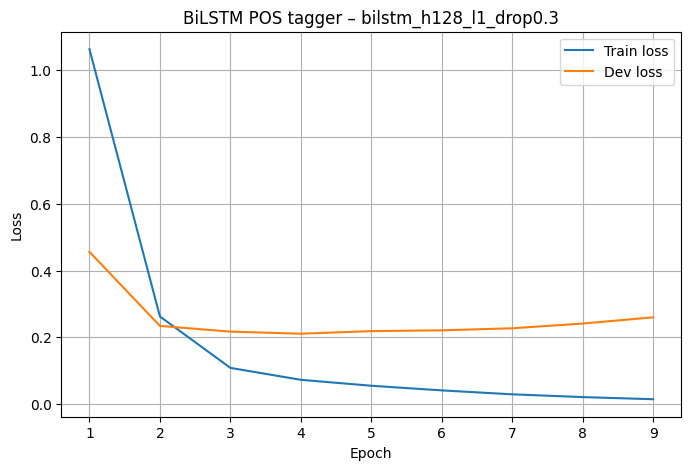

In [ ]:
# === LOSS CURVES FOR BEST BiLSTM ===
train_loss_rnn = best_rnn_history["train_loss"]
dev_loss_rnn   = best_rnn_history["dev_loss"]
epochs_rnn = range(1, len(train_loss_rnn) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_rnn, train_loss_rnn, label="Train loss")
plt.plot(epochs_rnn, dev_loss_rnn,   label="Dev loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"BiLSTM POS tagger – {best_rnn_config['name']}")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def make_results_row_from_preds(model_name, y_true, y_pred, y_proba, idx2tag):
    """
    Build one row with:
      P(tag), R(tag), F1(tag), PR-AUC(tag) for each tag,
      plus Macro-P/R/F1/PR-AUC,
    computed from y_true / y_pred / y_proba.
    """
    num_tags = len(idx2tag)
    label_order = list(range(num_tags))

    prf_dict = per_class_prf(y_true, y_pred, label_order)
    ap_dict  = per_class_prauc(y_true, y_proba, label_order)

    row = {"Model": model_name}
    per_class_vals = []

    for lbl in label_order:
        tag = idx2tag[lbl]
        P, R, F1 = prf_dict[lbl]
        A = ap_dict[lbl]
        row[f"P({tag})"]      = float(P)
        row[f"R({tag})"]      = float(R)
        row[f"F1({tag})"]     = float(F1)
        row[f"PR-AUC({tag})"] = float(A)
        per_class_vals.append((P, R, F1, A))

    macro_P, macro_R, macro_F1, macro_A = np.mean(per_class_vals, axis=0)
    row["Macro-P"]      = float(macro_P)
    row["Macro-R"]      = float(macro_R)
    row["Macro-F1"]     = float(macro_F1)
    row["Macro-PR-AUC"] = float(macro_A)
    return row


[ws5_emb100_h256_drop0.3] Epoch 1/20 | train loss: 0.5212 | dev loss: 0.2464 | dev macro-F1: 0.9159
[ws5_emb100_h256_drop0.3] Epoch 2/20 | train loss: 0.1120 | dev loss: 0.2129 | dev macro-F1: 0.9335
[ws5_emb100_h256_drop0.3] Epoch 3/20 | train loss: 0.0576 | dev loss: 0.2023 | dev macro-F1: 0.9329
[ws5_emb100_h256_drop0.3] Epoch 4/20 | train loss: 0.0360 | dev loss: 0.2246 | dev macro-F1: 0.9343
[ws5_emb100_h256_drop0.3] Epoch 5/20 | train loss: 0.0219 | dev loss: 0.2488 | dev macro-F1: 0.9336
[ws5_emb100_h256_drop0.3] Epoch 6/20 | train loss: 0.0154 | dev loss: 0.2934 | dev macro-F1: 0.9302
[ws5_emb100_h256_drop0.3] Epoch 7/20 | train loss: 0.0118 | dev loss: 0.3231 | dev macro-F1: 0.9296
[ws5_emb100_h256_drop0.3] Epoch 8/20 | train loss: 0.0096 | dev loss: 0.3272 | dev macro-F1: 0.9271
Early stopping (MLP).

=== Best MLP config (from 3b, retrained here) ===
{'name': 'ws5_emb100_h256_drop0.3', 'window_size': 5, 'emb_dim': 100, 'hidden_sizes': [256], 'dropout': 0.3, 'lr': 0.001, 'batc

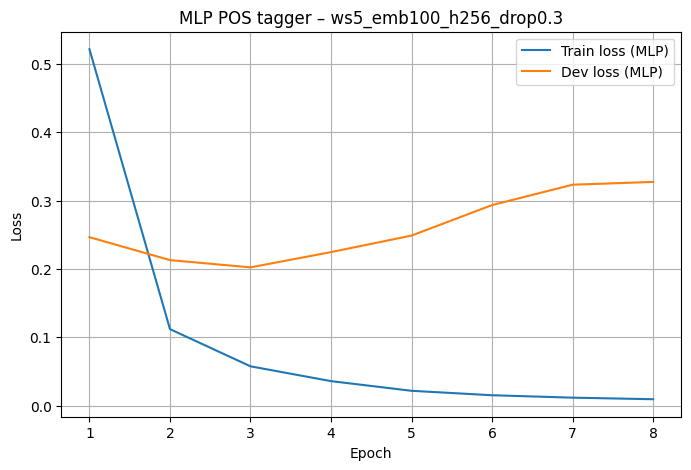


=== MLP POS TAGGER RESULTS (RECOMPUTED) ===

===== TRAIN (MLP) =====
Per-tag metrics:
Tag    ADJ | P=0.9954  R=0.9958  F1=0.9956  PR-AUC=0.9998
Tag    ADP | P=0.9980  R=0.9985  F1=0.9983  PR-AUC=1.0000
Tag    ADV | P=0.9943  R=0.9906  F1=0.9925  PR-AUC=0.9996
Tag    AUX | P=1.0000  R=0.9988  F1=0.9994  PR-AUC=1.0000
Tag  CCONJ | P=0.9912  R=0.9965  F1=0.9939  PR-AUC=0.9997
Tag    DET | P=0.9890  R=0.9940  F1=0.9915  PR-AUC=0.9996
Tag   INTJ | P=0.9979  R=0.9937  F1=0.9958  PR-AUC=0.9999
Tag   NOUN | P=0.9984  R=0.9986  F1=0.9985  PR-AUC=1.0000
Tag    NUM | P=0.9986  R=0.9937  F1=0.9961  PR-AUC=0.9999
Tag   PRON | P=0.9906  R=0.9831  F1=0.9869  PR-AUC=0.9991
Tag  PROPN | P=0.9972  R=0.9983  F1=0.9977  PR-AUC=1.0000
Tag  SCONJ | P=0.9848  R=0.9878  F1=0.9863  PR-AUC=0.9986
Tag   VERB | P=0.9999  R=0.9997  F1=0.9998  PR-AUC=1.0000

Macro-averaged:
  Macro-P:       0.9950
  Macro-R:       0.9946
  Macro-F1:      0.9948
  Macro-PR-AUC:  0.9997

===== DEV   (MLP) =====
Per-tag metrics:
Tag 

,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9845,0.9908,0.9876,0.9759,0.9765,0.9940,0.9852,0.9711,0.9726,...,0.8797,0.7775,0.9996,0.9992,0.9994,0.9989,0.9671,0.9665,0.9664,0.9384
1,MLP (best config),0.9954,0.9958,0.9956,0.9998,0.9980,0.9985,0.9983,1.0000,0.9943,...,0.9863,0.9986,0.9999,0.9997,0.9998,1.0000,0.9950,0.9946,0.9948,0.9997
2,BiLSTM,0.9990,0.9955,0.9972,1.0000,0.9991,0.9996,0.9993,1.0000,0.9978,...,0.9956,0.9998,0.9999,1.0000,1.0000,1.0000,0.9978,0.9978,0.9978,0.9999



=== DEV RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9774,0.7133,0.8247,0.7125,0.9683,0.9935,0.9807,0.9624,0.9556,...,0.8419,0.7201,0.7957,0.9989,0.8858,0.7950,0.9489,0.9039,0.9211,0.8627
1,MLP (best config),0.9135,0.7243,0.8080,0.8915,0.9892,0.9902,0.9897,0.9993,0.9599,...,0.9213,0.9750,0.8636,0.9787,0.9175,0.9845,0.9490,0.9236,0.9343,0.9749
2,BiLSTM,0.8574,0.7668,0.8096,0.8969,0.9924,0.9892,0.9908,0.9993,0.9643,...,0.9261,0.9631,0.8477,0.9918,0.9141,0.9833,0.9478,0.9268,0.9355,0.9737



=== TEST RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9730,0.7660,0.8571,0.7585,0.9723,0.9932,0.9827,0.9662,0.9746,...,0.8904,0.7953,0.7987,0.9976,0.8871,0.7972,0.9523,0.9197,0.9325,0.8811
1,MLP (best config),0.9181,0.7899,0.8492,0.9206,0.9932,0.9955,0.9944,0.9998,0.9664,...,0.9431,0.9817,0.8626,0.9739,0.9149,0.9807,0.9513,0.9303,0.9397,0.9766
2,BiLSTM,0.8580,0.8032,0.8297,0.9124,0.9966,0.9955,0.9960,0.9996,0.9721,...,0.9457,0.9849,0.8515,0.9820,0.9121,0.9791,0.9498,0.9335,0.9405,0.9753


In [ ]:
# ============================================================
# MLP BASELINE FROM ASSIGNMENT 3b
# ------------------------------------------------------------
# Uses:
#   - train_sents, dev_sents, test_sents
#   - word2idx, tag2idx, idx2tag
#   - embedding_weights (Word2Vec)
#   - per_class_prf, per_class_prauc, make_results_row_from_preds
#   - device
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ---------- 1. Windowed dataset for MLP (same as in 3b) ----------

def sentence_to_indices(words, word2idx):
    return [word2idx.get(w, word2idx[UNK_TOKEN]) for w in words]

def tags_to_indices(tags, tag2idx):
    return [tag2idx[t] for t in tags]

def make_windows(word_indices, tag_indices, window_size=5, pad_id=None):
    assert len(word_indices) == len(tag_indices)
    if pad_id is None:
        pad_id = word2idx[PAD_TOKEN]
    k = window_size // 2
    padded = [pad_id] * k + word_indices + [pad_id] * k

    X, y = [], []
    for i in range(len(word_indices)):
        window = padded[i : i + window_size]
        X.append(window)
        y.append(tag_indices[i])
    return X, y

def dataset_to_windows(sentences, word2idx, tag2idx, window_size=5):
    all_X, all_y = [], []
    for words, tags in sentences:
        w_idx = sentence_to_indices(words, word2idx)
        t_idx = tags_to_indices(tags, tag2idx)
        X, y = make_windows(w_idx, t_idx, window_size=window_size, pad_id=word2idx[PAD_TOKEN])
        all_X.extend(X)
        all_y.extend(y)
    return all_X, all_y

class WindowPOSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ---------- 2. MLP model (exactly as in 3b) ----------

class MLP_POS(nn.Module):
    def __init__(self, vocab_size, num_tags, window_size, config, embedding_weights=None):
        super().__init__()
        self.vocab_size = vocab_size
        self.num_tags = num_tags
        self.window_size = window_size

        emb_dim = config["emb_dim"]
        hidden_sizes = config["hidden_sizes"]
        dropout_p = config["dropout"]

        # Embedding layer (initialized with Word2Vec)
        if embedding_weights is not None:
            self.embedding = nn.Embedding.from_pretrained(
                embedding_weights, freeze=False  # fine-tune embeddings
            )
        else:
            self.embedding = nn.Embedding(vocab_size, emb_dim)

        layers = []
        input_dim = emb_dim * window_size

        for h in hidden_sizes:
            layers.append(nn.Linear(input_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_p))
            input_dim = h

        layers.append(nn.Linear(input_dim, num_tags))  # final layer
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: [batch_size, window_size]
        emb = self.embedding(x)           # [B, W, emb_dim]
        emb = emb.view(emb.size(0), -1)   # [B, W*emb_dim]
        logits = self.mlp(emb)            # [B, num_tags]
        return logits


# ---------- 3. Helpers for training & evaluation ----------

from sklearn.metrics import precision_recall_fscore_support, average_precision_score
import numpy as np

def predict_loader(model, loader, device):
    model.eval()
    all_y_true, all_y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_y_pred.append(preds)
            all_y_true.append(yb.cpu().numpy())
    return np.concatenate(all_y_true), np.concatenate(all_y_pred)

def predict_proba_loader(model, loader, device):
    model.eval()
    all_y_true, all_y_pred, all_y_proba = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            all_y_true.append(yb.numpy())
            all_y_pred.append(preds)
            all_y_proba.append(probs)

    return (
        np.concatenate(all_y_true),
        np.concatenate(all_y_pred),
        np.concatenate(all_y_proba),
    )

def compute_macro_f1_mlp(model, loader, device):
    y_true, y_pred = predict_loader(model, loader, device)
    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return macro_f1

def train_one_mlp_config(config, train_dataset, dev_dataset, vocab_size, num_tags, device, embedding_weights):
    """
    Train a single MLP_POS with given config and return:
      model with best dev macro-F1,
      history dict with train/dev loss,
      best_dev_macro_f1
    """
    batch_size = config["batch_size"]
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    dev_loader   = DataLoader(dev_dataset,   batch_size=batch_size, shuffle=False)

    model = MLP_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        window_size=config["window_size"],
        config=config,
        embedding_weights=embedding_weights,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=config["lr"])

    history = {"train_loss": [], "dev_loss": []}
    best_dev_macro_f1 = -1.0
    best_state_dict = None
    patience = 5

    for epoch in range(config["num_epochs"]):
        # ---- TRAIN ----
        model.train()
        running_train_loss = 0.0
        total_train = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * xb.size(0)
            total_train += xb.size(0)

        epoch_train_loss = running_train_loss / total_train
        history["train_loss"].append(epoch_train_loss)

        # ---- DEV LOSS ----
        model.eval()
        running_dev_loss = 0.0
        total_dev = 0
        with torch.no_grad():
            for xb, yb in dev_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                running_dev_loss += loss.item() * xb.size(0)
                total_dev += xb.size(0)
        epoch_dev_loss = running_dev_loss / total_dev
        history["dev_loss"].append(epoch_dev_loss)

        # ---- DEV MACRO-F1 ----
        dev_macro_f1 = compute_macro_f1_mlp(model, dev_loader, device)

        print(
            f"[{config['name']}] Epoch {epoch+1}/{config['num_epochs']} | "
            f"train loss: {epoch_train_loss:.4f} | dev loss: {epoch_dev_loss:.4f} | "
            f"dev macro-F1: {dev_macro_f1:.4f}"
        )

        if dev_macro_f1 > best_dev_macro_f1:
            best_dev_macro_f1 = dev_macro_f1
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # simple early stopping on dev loss
        if len(history["dev_loss"]) > patience:
            window = history["dev_loss"][-(patience + 1):]
            worsening = all(window[i] > window[i - 1] for i in range(1, len(window)))
            if worsening:
                print("Early stopping (MLP).")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        model.to(device)

    return model, history, best_dev_macro_f1


# ---------- 4. Build window datasets & train MLP with tuned config ----------

vocab_size = len(word2idx)
num_tags   = len(tag2idx)

mlp_best_config = {
    "name": "ws5_emb100_h256_drop0.3",
    "window_size": 5,
    "emb_dim": 100,
    "hidden_sizes": [256],
    "dropout": 0.3,
    "lr": 1e-3,
    "batch_size": 128,
    "num_epochs": 20,
}

# Windowed data (reuse same word2idx/tag2idx as RNN & baseline)
x_train_m, y_train_m = dataset_to_windows(train_sents, word2idx, tag2idx, mlp_best_config["window_size"])
x_dev_m,   y_dev_m   = dataset_to_windows(dev_sents,   word2idx, tag2idx, mlp_best_config["window_size"])
x_test_m,  y_test_m  = dataset_to_windows(test_sents,  word2idx, tag2idx, mlp_best_config["window_size"])

train_dataset_mlp = WindowPOSDataset(x_train_m, y_train_m)
dev_dataset_mlp   = WindowPOSDataset(x_dev_m,   y_dev_m)
test_dataset_mlp  = WindowPOSDataset(x_test_m,  y_test_m)

mlp_model, mlp_history, mlp_best_dev_macro_f1 = train_one_mlp_config(
    mlp_best_config,
    train_dataset=train_dataset_mlp,
    dev_dataset=dev_dataset_mlp,
    vocab_size=vocab_size,
    num_tags=num_tags,
    device=device,
    embedding_weights=embedding_weights,
)

print("\n=== Best MLP config (from 3b, retrained here) ===")
print(mlp_best_config)
print(f"Best Dev Macro-F1 (MLP): {mlp_best_dev_macro_f1:.4f}")

# Plot MLP loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(mlp_history["train_loss"]) + 1), mlp_history["train_loss"], label="Train loss (MLP)")
plt.plot(range(1, len(mlp_history["dev_loss"]) + 1),   mlp_history["dev_loss"],   label="Dev loss (MLP)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"MLP POS tagger – {mlp_best_config['name']}")
plt.legend()
plt.grid(True)
plt.show()


# ---------- 5. Get MLP predictions & probabilities on TRAIN / DEV / TEST ----------

batch_size_mlp_eval = 128
train_loader_mlp = DataLoader(train_dataset_mlp, batch_size=batch_size_mlp_eval, shuffle=False)
dev_loader_mlp   = DataLoader(dev_dataset_mlp,   batch_size=batch_size_mlp_eval, shuffle=False)
test_loader_mlp  = DataLoader(test_dataset_mlp,  batch_size=batch_size_mlp_eval, shuffle=False)

y_train_true_m, y_train_pred_m, y_train_proba_m = predict_proba_loader(mlp_model, train_loader_mlp, device)
y_dev_true_m,   y_dev_pred_m,   y_dev_proba_m   = predict_proba_loader(mlp_model, dev_loader_mlp,   device)
y_test_true_m,  y_test_pred_m,  y_test_proba_m  = predict_proba_loader(mlp_model, test_loader_mlp,  device)

print("\n=== MLP POS TAGGER RESULTS (RECOMPUTED) ===")
evaluate_split_full("TRAIN (MLP)", y_train_true_m, y_train_pred_m, y_train_proba_m, idx2tag)
evaluate_split_full("DEV   (MLP)", y_dev_true_m,   y_dev_pred_m,   y_dev_proba_m,   idx2tag)
evaluate_split_full("TEST  (MLP)", y_test_true_m,  y_test_pred_m,  y_test_proba_m,  idx2tag)


# ============================================================
# 6. FINAL COMPARISON TABLES: Baseline vs MLP vs BiLSTM
# ============================================================

baseline_train_row = make_results_row_from_preds(
    "Baseline", y_train_true_b, y_train_pred_b, y_train_proba_b, idx2tag
)
bilstm_train_row = make_results_row_from_preds(
    "BiLSTM",  y_train_true_r, y_train_pred_r, y_train_proba_r, idx2tag
)
mlp_train_row = make_results_row_from_preds(
    "MLP (best config)", y_train_true_m, y_train_pred_m, y_train_proba_m, idx2tag
)

baseline_dev_row = make_results_row_from_preds(
    "Baseline", y_dev_true_b, y_dev_pred_b, y_dev_proba_b, idx2tag
)
bilstm_dev_row = make_results_row_from_preds(
    "BiLSTM",  y_dev_true_r, y_dev_pred_r, y_dev_proba_r, idx2tag
)
mlp_dev_row = make_results_row_from_preds(
    "MLP (best config)", y_dev_true_m, y_dev_pred_m, y_dev_proba_m, idx2tag
)

baseline_test_row = make_results_row_from_preds(
    "Baseline", y_test_true_b, y_test_pred_b, y_test_proba_b, idx2tag
)
bilstm_test_row = make_results_row_from_preds(
    "BiLSTM",  y_test_true_r, y_test_pred_r, y_test_proba_r, idx2tag
)
mlp_test_row = make_results_row_from_preds(
    "MLP (best config)", y_test_true_m, y_test_pred_m, y_test_proba_m, idx2tag
)

# Column order
tags = [idx2tag[i] for i in range(len(idx2tag))]
cols = ["Model"]
for t in tags:
    cols += [f"P({t})", f"R({t})", f"F1({t})", f"PR-AUC({t})"]
cols += ["Macro-P", "Macro-R", "Macro-F1", "Macro-PR-AUC"]

# Build DataFrames
train_rows = [baseline_train_row, mlp_train_row, bilstm_train_row]
dev_rows   = [baseline_dev_row,   mlp_dev_row,   bilstm_dev_row]
test_rows  = [baseline_test_row,  mlp_test_row,  bilstm_test_row]

train_df = pd.DataFrame(train_rows)[cols]
dev_df   = pd.DataFrame(dev_rows)[cols]
test_df  = pd.DataFrame(test_rows)[cols]

pd.options.display.float_format = "{:.4f}".format

print("=== TRAIN RESULTS ===")
display(train_df)

print("\n=== DEV RESULTS ===")
display(dev_df)

print("\n=== TEST RESULTS ===")
display(test_df)


In [ ]:
from collections import Counter

CHAR_PAD = "<CPAD>"
CHAR_UNK = "<CUNK>"

def build_char_vocab(sentences):
    """
    Build a character vocabulary from the training sentences.
    """
    counter = Counter()
    for words, _ in sentences:
        for w in words:
            counter.update(list(w))

    char2idx = {CHAR_PAD: 0, CHAR_UNK: 1}
    idx2char = [CHAR_PAD, CHAR_UNK]

    for ch, _ in counter.most_common():
        if ch not in char2idx:
            char2idx[ch] = len(idx2char)
            idx2char.append(ch)

    return char2idx, idx2char

char2idx, idx2char = build_char_vocab(train_sents)
char_pad_idx = char2idx[CHAR_PAD]

print("Char vocab size:", len(char2idx))


Char vocab size: 177


In [ ]:
class SentencePOSDatasetWithChars(Dataset):
    """
    Each item:
      - word_ids: LongTensor [seq_len]
      - tag_ids:  LongTensor [seq_len]
      - char_ids: list of LongTensors, each [word_len]
    """
    def __init__(self, sentences, word2idx, tag2idx, char2idx):
        self.sent_word_ids = []
        self.sent_tag_ids = []
        self.sent_char_ids = []

        for words, tags in sentences:
            w_ids = [word2idx.get(w, word2idx[UNK_TOKEN]) for w in words]
            t_ids = [tag2idx[t] for t in tags]

            char_seqs = []
            for w in words:
                ch_ids = [char2idx.get(ch, char2idx[CHAR_UNK]) for ch in w]
                char_seqs.append(torch.tensor(ch_ids, dtype=torch.long))

            assert len(w_ids) == len(t_ids) == len(char_seqs)
            self.sent_word_ids.append(torch.tensor(w_ids, dtype=torch.long))
            self.sent_tag_ids.append(torch.tensor(t_ids, dtype=torch.long))
            self.sent_char_ids.append(char_seqs)

    def __len__(self):
        return len(self.sent_word_ids)

    def __getitem__(self, idx):
        return self.sent_word_ids[idx], self.sent_tag_ids[idx], self.sent_char_ids[idx]


In [ ]:
train_seq_dataset_chars = SentencePOSDatasetWithChars(train_sents, word2idx, tag2idx, char2idx)
dev_seq_dataset_chars   = SentencePOSDatasetWithChars(dev_sents,   word2idx, tag2idx, char2idx)
test_seq_dataset_chars  = SentencePOSDatasetWithChars(test_sents,  word2idx, tag2idx, char2idx)

print("Char-aware datasets:",
      len(train_seq_dataset_chars),
      len(dev_seq_dataset_chars),
      len(test_seq_dataset_chars))


Char-aware datasets: 15016 1019 1047


In [ ]:
def collate_sentences_with_chars(batch):
    """
    batch: list of (word_ids, tag_ids, char_ids_list)
      word_ids: LongTensor [L]
      tag_ids:  LongTensor [L]
      char_ids_list: list of LongTensors [len(word_i)]

    Returns:
      X_words:  [B, T]
      X_chars:  [B, T, W]   (char ids, padded)
      y:        [B, T]      (with IGNORED_TAG_INDEX in padded positions)
      lengths:  [B]
    """
    word_seqs, tag_seqs, char_seqs_list = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in word_seqs], dtype=torch.long)
    max_len = lengths.max().item()
    batch_size = len(word_seqs)

    # word + tag padding
    X_words = torch.full((batch_size, max_len), pad_idx, dtype=torch.long)
    y       = torch.full((batch_size, max_len), IGNORED_TAG_INDEX, dtype=torch.long)

    # max word length in this batch
    max_word_len = 1
    for sent_chars in char_seqs_list:
        for ch_seq in sent_chars:
            if len(ch_seq) > max_word_len:
                max_word_len = len(ch_seq)

    X_chars = torch.full(
        (batch_size, max_len, max_word_len),
        char_pad_idx,
        dtype=torch.long
    )

    # fill
    for i, (w_seq, t_seq, sent_chars) in enumerate(zip(word_seqs, tag_seqs, char_seqs_list)):
        L = len(w_seq)
        X_words[i, :L] = w_seq
        y[i, :L]       = t_seq

        for j, ch_seq in enumerate(sent_chars):
            cl = len(ch_seq)
            X_chars[i, j, :cl] = ch_seq

    return X_words, X_chars, y, lengths


In [ ]:
class CharAwareBiLSTM_POS(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_tags,
        config,
        embedding_weights=None,
        pad_idx=0,
        char_vocab_size=None,
        char_pad_idx=0,
    ):
        super().__init__()
        self.pad_idx = pad_idx
        self.use_char_rnn = config.get("use_char_rnn", True)

        emb_dim        = config["emb_dim"]
        hidden_dim     = config["hidden_dim"]
        num_layers     = config["num_layers"]
        rnn_dropout    = config["rnn_dropout"]
        fc_dropout     = config["fc_dropout"]
        char_emb_dim   = config.get("char_emb_dim", 50)
        char_hidden_dim= config.get("char_hidden_dim", 50)

        # ----- Word embedding -----
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=emb_dim,
            padding_idx=pad_idx,
        )
        if embedding_weights is not None:
            self.embedding.weight.data.copy_(embedding_weights)

        # ----- Char-level BiLSTM -----
        if self.use_char_rnn:
            assert char_vocab_size is not None, "char_vocab_size must be provided"
            self.char_embedding = nn.Embedding(
                num_embeddings=char_vocab_size,
                embedding_dim=char_emb_dim,
                padding_idx=char_pad_idx,
            )
            self.char_lstm = nn.LSTM(
                input_size=char_emb_dim,
                hidden_size=char_hidden_dim,
                num_layers=1,
                batch_first=True,
                bidirectional=True,
            )
            rnn_input_dim = emb_dim + 2 * char_hidden_dim
        else:
            rnn_input_dim = emb_dim

        # ----- Word-level BiLSTM -----
        self.lstm = nn.LSTM(
            input_size=rnn_input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=rnn_dropout if num_layers > 1 else 0.0,
        )

        # ----- Final classifier -----
        self.dropout = nn.Dropout(fc_dropout)
        self.fc = nn.Linear(2 * hidden_dim, num_tags)

    def forward(self, x_words, lengths, x_chars=None):
        """
        x_words: [B, T]
        x_chars: [B, T, W] or None
        lengths: [B]
        """
        B, T = x_words.size()
        word_emb = self.embedding(x_words)  # [B, T, emb_dim]

        if self.use_char_rnn and x_chars is not None:
            B, T, W = x_chars.size()
            # char_emb: [B*T, W, char_emb_dim]
            char_emb = self.char_embedding(x_chars.view(B * T, W))
            # run char BiLSTM
            _, (h_n, _) = self.char_lstm(char_emb)  # h_n: [2, B*T, char_hidden_dim]
            # concatenate final forward/backward hidden states
            char_rep = torch.cat([h_n[-2], h_n[-1]], dim=-1)  # [B*T, 2*char_hidden_dim]
            char_rep = char_rep.view(B, T, -1)
            # concat word + char reps
            word_rep = torch.cat([word_emb, char_rep], dim=-1)
        else:
            word_rep = word_emb

        # word-level BiLSTM over sequence
        packed = nn.utils.rnn.pack_padded_sequence(
            word_rep, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        out = self.dropout(out)
        logits = self.fc(out)  # [B, T, num_tags]
        return logits


In [ ]:
def train_one_char_rnn_config(
    config,
    train_dataset,
    dev_dataset,
    vocab_size,
    char_vocab_size,
    num_tags,
    device,
    patience=5,
):
    batch_size = config["batch_size"]

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_sentences_with_chars,
    )
    dev_loader = DataLoader(
        dev_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_sentences_with_chars,
    )

    model = CharAwareBiLSTM_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
        char_vocab_size=char_vocab_size,
        char_pad_idx=char_pad_idx,
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=IGNORED_TAG_INDEX)
    optimizer = Adam(model.parameters(), lr=config["lr"])

    history = {"train_loss": [], "dev_loss": []}
    best_dev_macro_f1 = -1.0
    best_state = None

    for epoch in range(config["num_epochs"]):
        # ----- TRAIN -----
        model.train()
        running_train_loss = 0.0
        total_tokens_train = 0

        for Xw, Xc, yb, lengths in train_loader:
            Xw, Xc, yb, lengths = Xw.to(device), Xc.to(device), yb.to(device), lengths.to(device)
            optimizer.zero_grad()

            logits = model(Xw, lengths, Xc)         # [B, T, C]
            B, T, C = logits.shape
            loss = criterion(logits.view(-1, C), yb.view(-1))
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_train_loss += loss.item() * num_tokens
                total_tokens_train += num_tokens

        epoch_train_loss = running_train_loss / max(total_tokens_train, 1)
        history["train_loss"].append(epoch_train_loss)

        # ----- DEV LOSS -----
        model.eval()
        running_dev_loss = 0.0
        total_tokens_dev = 0
        with torch.no_grad():
            for Xw, Xc, yb, lengths in dev_loader:
                Xw, Xc, yb, lengths = Xw.to(device), Xc.to(device), yb.to(device), lengths.to(device)
                logits = model(Xw, lengths, Xc)
                B, T, C = logits.shape
                loss = criterion(logits.view(-1, C), yb.view(-1))

                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_dev_loss += loss.item() * num_tokens
                total_tokens_dev += num_tokens

        epoch_dev_loss = running_dev_loss / max(total_tokens_dev, 1)
        history["dev_loss"].append(epoch_dev_loss)

        # ----- DEV MACRO-F1 -----
        y_true_dev, y_pred_dev, _ = predict_seq_with_proba_char(
            model, dev_loader, device
        )
        _, _, macro_f1, _ = precision_recall_fscore_support(
            y_true_dev, y_pred_dev, average="macro", zero_division=0
        )

        print(
            f"[{config['name']}] Epoch {epoch+1}/{config['num_epochs']} | "
            f"train loss: {epoch_train_loss:.4f} | dev loss: {epoch_dev_loss:.4f} | "
            f"dev macro-F1: {macro_f1:.4f}"
        )

        if macro_f1 > best_dev_macro_f1:
            best_dev_macro_f1 = macro_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # early stopping on dev loss
        if len(history["dev_loss"]) > patience:
            window = history["dev_loss"][-(patience + 1):]
            worsening = all(window[i] > window[i - 1] for i in range(1, len(window)))
            if worsening:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    return model, history, best_dev_macro_f1


In [ ]:
def predict_seq_with_proba_char(model, loader, device):
    model.eval()
    all_true, all_pred, all_proba = [], [], []

    with torch.no_grad():
        for Xw, Xc, yb, lengths in loader:
            Xw, Xc, yb, lengths = Xw.to(device), Xc.to(device), yb.to(device), lengths.to(device)
            logits = model(Xw, lengths, Xc)
            proba = F.softmax(logits, dim=-1)

            B, T, C = proba.shape
            proba_flat = proba.view(-1, C)
            y_flat = yb.view(-1)

            mask = (y_flat != IGNORED_TAG_INDEX)
            y_true = y_flat[mask].cpu().numpy()
            y_proba = proba_flat[mask].cpu().numpy()
            y_pred = np.argmax(y_proba, axis=1)

            all_true.append(y_true)
            all_pred.append(y_pred)
            all_proba.append(y_proba)

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    y_proba = np.vstack(all_proba)
    return y_true, y_pred, y_proba


In [ ]:
def train_one_rnn_with_temporal_averaging(
    config,
    train_dataset,
    dev_dataset,
    vocab_size,
    num_tags,
    device,
    patience=5,
):
    """
    Independent trainer that:
      - trains a BiLSTM_POS with the given config
      - keeps both:
          best checkpoint by dev macro-F1
          temporal average of weights over epochs
    Returns:
      best_model, avg_model, history, best_dev_macro_f1, avg_dev_macro_f1
    """
    batch_size = config["batch_size"]

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_sentences,
    )
    dev_loader = DataLoader(
        dev_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_sentences,
    )

    model = BiLSTM_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=IGNORED_TAG_INDEX)
    optimizer = Adam(model.parameters(), lr=config["lr"])

    history = {"train_loss": [], "dev_loss": []}

    best_dev_macro_f1 = -1.0
    best_state_dict = None

    # for temporal averaging
    avg_state_dict = None
    avg_count = 0

    for epoch in range(config["num_epochs"]):
        # ----- TRAIN -----
        model.train()
        running_train_loss = 0.0
        total_tokens_train = 0

        for Xb, yb, lengths in train_loader:
            Xb, yb, lengths = Xb.to(device), yb.to(device), lengths.to(device)
            optimizer.zero_grad()

            logits = model(Xb, lengths)          # [B, T, C]
            B, T, C = logits.shape
            loss = criterion(logits.view(-1, C), yb.view(-1))
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_train_loss += loss.item() * num_tokens
                total_tokens_train += num_tokens

        epoch_train_loss = running_train_loss / max(total_tokens_train, 1)
        history["train_loss"].append(epoch_train_loss)

        # ----- DEV LOSS -----
        model.eval()
        running_dev_loss = 0.0
        total_tokens_dev = 0
        with torch.no_grad():
            for Xb, yb, lengths in dev_loader:
                Xb, yb, lengths = Xb.to(device), yb.to(device), lengths.to(device)
                logits = model(Xb, lengths)
                B, T, C = logits.shape
                loss = criterion(logits.view(-1, C), yb.view(-1))

                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_dev_loss += loss.item() * num_tokens
                total_tokens_dev += num_tokens

        epoch_dev_loss = running_dev_loss / max(total_tokens_dev, 1)
        history["dev_loss"].append(epoch_dev_loss)

        # ----- DEV MACRO-F1 -----
        dev_macro_f1 = compute_macro_f1_seq(model, dev_loader, device)

        print(
            f"[{config['name']} (TA)] Epoch {epoch+1}/{config['num_epochs']} | "
            f"train loss: {epoch_train_loss:.4f} | dev loss: {epoch_dev_loss:.4f} | "
            f"dev macro-F1: {dev_macro_f1:.4f}"
        )

        # Update best checkpoint
        if dev_macro_f1 > best_dev_macro_f1:
            best_dev_macro_f1 = dev_macro_f1
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # Update temporal average of weights
        with torch.no_grad():
            current_state = model.state_dict()
            if avg_state_dict is None:
                avg_state_dict = {k: v.cpu().clone() for k, v in current_state.items()}
                avg_count = 1
            else:
                avg_count += 1
                for k, v in current_state.items():
                    avg_state_dict[k].mul_((avg_count - 1) / avg_count).add_(v.cpu() / avg_count)

        # Early stopping on dev loss
        if len(history["dev_loss"]) > patience:
            window = history["dev_loss"][-(patience + 1):]
            worsening = all(window[i] > window[i - 1] for i in range(1, len(window)))
            if worsening:
                print("Early stopping triggered (temporal-avg trainer).")
                break

    # ----- Build best-model and avg-model -----
    # best checkpoint
    best_model = BiLSTM_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
    ).to(device)
    if best_state_dict is not None:
        best_model.load_state_dict(best_state_dict)

    # temporal-averaged model
    avg_model = BiLSTM_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
    ).to(device)
    if avg_state_dict is not None:
        avg_model.load_state_dict(avg_state_dict)

    # compute dev macro-F1 of averaged model
    dev_macro_f1_avg = compute_macro_f1_seq(avg_model, dev_loader, device)

    print(f"\n[{config['name']} (TA)] Best dev macro-F1 (single ckpt): {best_dev_macro_f1:.4f}")
    print(f"[{config['name']} (TA)] Dev macro-F1 (temporal avg):      {dev_macro_f1_avg:.4f}")

    return best_model, avg_model, history, best_dev_macro_f1, dev_macro_f1_avg


In [ ]:
char_rnn_config = {
    "name": "bilstm_char+word_h128_l2",
    "emb_dim": embedding_weights.shape[1],
    "hidden_dim": 128,
    "num_layers": 2,
    "rnn_dropout": 0.3,
    "fc_dropout": 0.5,
    "char_emb_dim": 50,
    "char_hidden_dim": 50,
    "use_char_rnn": True,
    "lr": 1e-3,
    "batch_size": 64,
    "num_epochs": 20,
}

best_char_model, char_history, char_dev_macro_f1 = train_one_char_rnn_config(
    char_rnn_config,
    train_seq_dataset_chars,
    dev_seq_dataset_chars,
    vocab_size=vocab_size,
    char_vocab_size=len(char2idx),
    num_tags=num_tags,
    device=device,
    patience=5,
)

print("Best char-aware dev macro-F1:", char_dev_macro_f1)


[bilstm_char+word_h128_l2] Epoch 1/20 | train loss: 0.5663 | dev loss: 0.1876 | dev macro-F1: 0.9397
[bilstm_char+word_h128_l2] Epoch 2/20 | train loss: 0.0615 | dev loss: 0.2030 | dev macro-F1: 0.9413
[bilstm_char+word_h128_l2] Epoch 3/20 | train loss: 0.0367 | dev loss: 0.2027 | dev macro-F1: 0.9385
[bilstm_char+word_h128_l2] Epoch 4/20 | train loss: 0.0232 | dev loss: 0.2387 | dev macro-F1: 0.9396
[bilstm_char+word_h128_l2] Epoch 5/20 | train loss: 0.0158 | dev loss: 0.2346 | dev macro-F1: 0.9386
[bilstm_char+word_h128_l2] Epoch 6/20 | train loss: 0.0105 | dev loss: 0.2499 | dev macro-F1: 0.9378
[bilstm_char+word_h128_l2] Epoch 7/20 | train loss: 0.0086 | dev loss: 0.3274 | dev macro-F1: 0.9374
[bilstm_char+word_h128_l2] Epoch 8/20 | train loss: 0.0056 | dev loss: 0.2914 | dev macro-F1: 0.9363
[bilstm_char+word_h128_l2] Epoch 9/20 | train loss: 0.0045 | dev loss: 0.3362 | dev macro-F1: 0.9337
[bilstm_char+word_h128_l2] Epoch 10/20 | train loss: 0.0038 | dev loss: 0.3678 | dev macro-

In [ ]:
# === EVALUATE CHAR-AWARE BiLSTM ON TRAIN / DEV / TEST ===

eval_batch_size = 64
train_seq_loader_chars = DataLoader(
    train_seq_dataset_chars,
    batch_size=eval_batch_size,
    shuffle=False,
    collate_fn=collate_sentences_with_chars,
)
dev_seq_loader_chars = DataLoader(
    dev_seq_dataset_chars,
    batch_size=eval_batch_size,
    shuffle=False,
    collate_fn=collate_sentences_with_chars,
)
test_seq_loader_chars = DataLoader(
    test_seq_dataset_chars,
    batch_size=eval_batch_size,
    shuffle=False,
    collate_fn=collate_sentences_with_chars,
)

y_train_true_c, y_train_pred_c, y_train_proba_c = predict_seq_with_proba_char(
    best_char_model, train_seq_loader_chars, device
)
y_dev_true_c, y_dev_pred_c, y_dev_proba_c = predict_seq_with_proba_char(
    best_char_model, dev_seq_loader_chars, device
)
y_test_true_c, y_test_pred_c, y_test_proba_c = predict_seq_with_proba_char(
    best_char_model, test_seq_loader_chars, device
)

print("\n\n=== Char+Word BiLSTM POS TAGGER RESULTS ===")
evaluate_split_full("TRAIN (BiLSTM-char)", y_train_true_c, y_train_pred_c, y_train_proba_c, idx2tag)
evaluate_split_full("DEV   (BiLSTM-char)", y_dev_true_c,   y_dev_pred_c,   y_dev_proba_c,   idx2tag)
evaluate_split_full("TEST  (BiLSTM-char)", y_test_true_c,  y_test_pred_c,  y_test_proba_c,  idx2tag)




=== Char+Word BiLSTM POS TAGGER RESULTS ===

===== TRAIN (BiLSTM-char) =====
Per-tag metrics:
Tag    ADJ | P=0.9946  R=0.9911  F1=0.9928  PR-AUC=0.9996
Tag    ADP | P=0.9942  R=0.9982  F1=0.9962  PR-AUC=0.9998
Tag    ADV | P=0.9922  R=0.9657  F1=0.9788  PR-AUC=0.9981
Tag    AUX | P=0.9985  R=0.9983  F1=0.9984  PR-AUC=0.9998
Tag  CCONJ | P=0.9727  R=0.9950  F1=0.9838  PR-AUC=0.9987
Tag    DET | P=0.9909  R=0.9763  F1=0.9835  PR-AUC=0.9989
Tag   INTJ | P=0.9958  R=0.9958  F1=0.9958  PR-AUC=0.9991
Tag   NOUN | P=0.9971  R=0.9988  F1=0.9979  PR-AUC=1.0000
Tag    NUM | P=0.9979  R=0.9845  F1=0.9912  PR-AUC=0.9988
Tag   PRON | P=0.9640  R=0.9858  F1=0.9748  PR-AUC=0.9971
Tag  PROPN | P=0.9957  R=0.9970  F1=0.9964  PR-AUC=0.9997
Tag  SCONJ | P=0.9344  R=0.9789  F1=0.9562  PR-AUC=0.9894
Tag   VERB | P=0.9998  R=0.9997  F1=0.9997  PR-AUC=1.0000

Macro-averaged:
  Macro-P:       0.9868
  Macro-R:       0.9896
  Macro-F1:      0.9881
  Macro-PR-AUC:  0.9984

===== DEV   (BiLSTM-char) =====
Per-

{'Macro-P': np.float64(0.9545531673416568),
 'Macro-R': np.float64(0.9359718754812852),
 'Macro-F1': np.float64(0.9434669945098074),
 'Macro-PR-AUC': np.float64(0.981166175217905)}

In [ ]:
baseline_train_row = make_results_row_from_preds(
    "Baseline", y_train_true_b, y_train_pred_b, y_train_proba_b, idx2tag
)
mlp_train_row = make_results_row_from_preds(
    "MLP (best config)", y_train_true_m, y_train_pred_m, y_train_proba_m, idx2tag
)
bilstm_train_row = make_results_row_from_preds(
    "BiLSTM",  y_train_true_r, y_train_pred_r, y_train_proba_r, idx2tag
)

baseline_dev_row = make_results_row_from_preds(
    "Baseline", y_dev_true_b, y_dev_pred_b, y_dev_proba_b, idx2tag
)
mlp_dev_row = make_results_row_from_preds(
    "MLP (best config)", y_dev_true_m, y_dev_pred_m, y_dev_proba_m, idx2tag
)
bilstm_dev_row = make_results_row_from_preds(
    "BiLSTM",  y_dev_true_r, y_dev_pred_r, y_dev_proba_r, idx2tag
)

baseline_test_row = make_results_row_from_preds(
    "Baseline", y_test_true_b, y_test_pred_b, y_test_proba_b, idx2tag
)
mlp_test_row = make_results_row_from_preds(
    "MLP (best config)", y_test_true_m, y_test_pred_m, y_test_proba_m, idx2tag
)
bilstm_test_row = make_results_row_from_preds(
    "BiLSTM",  y_test_true_r, y_test_pred_r, y_test_proba_r, idx2tag
)

bilstm_char_train_row = make_results_row_from_preds(
    "BiLSTM-char", y_train_true_c, y_train_pred_c, y_train_proba_c, idx2tag
)
bilstm_char_dev_row = make_results_row_from_preds(
    "BiLSTM-char", y_dev_true_c, y_dev_pred_c, y_dev_proba_c, idx2tag
)
bilstm_char_test_row = make_results_row_from_preds(
    "BiLSTM-char", y_test_true_c, y_test_pred_c, y_test_proba_c, idx2tag
)

# Column order
tags = [idx2tag[i] for i in range(len(idx2tag))]
cols = ["Model"]
for t in tags:
    cols += [f"P({t})", f"R({t})", f"F1({t})", f"PR-AUC({t})"]
cols += ["Macro-P", "Macro-R", "Macro-F1", "Macro-PR-AUC"]

# Build DataFrames
train_rows = [baseline_train_row, mlp_train_row, bilstm_train_row, bilstm_char_train_row]
dev_rows   = [baseline_dev_row,   mlp_dev_row,   bilstm_dev_row,   bilstm_char_dev_row]
test_rows  = [baseline_test_row,  mlp_test_row,  bilstm_test_row,  bilstm_char_test_row]

train_df = pd.DataFrame(train_rows)[cols]
dev_df   = pd.DataFrame(dev_rows)[cols]
test_df  = pd.DataFrame(test_rows)[cols]

pd.options.display.float_format = "{:.4f}".format

print("=== TRAIN RESULTS ===")
display(train_df)

print("\n=== DEV RESULTS ===")
display(dev_df)

print("\n=== TEST RESULTS ===")
display(test_df)


=== TRAIN RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9845,0.9908,0.9876,0.9759,0.9765,0.9940,0.9852,0.9711,0.9726,...,0.8797,0.7775,0.9996,0.9992,0.9994,0.9989,0.9671,0.9665,0.9664,0.9384
1,MLP (best config),0.9954,0.9958,0.9956,0.9998,0.9980,0.9985,0.9983,1.0000,0.9943,...,0.9863,0.9986,0.9999,0.9997,0.9998,1.0000,0.9950,0.9946,0.9948,0.9997
2,BiLSTM,0.9990,0.9955,0.9972,1.0000,0.9991,0.9996,0.9993,1.0000,0.9978,...,0.9956,0.9998,0.9999,1.0000,1.0000,1.0000,0.9978,0.9978,0.9978,0.9999
3,BiLSTM-char,0.9946,0.9911,0.9928,0.9996,0.9942,0.9982,0.9962,0.9998,0.9922,...,0.9562,0.9894,0.9998,0.9997,0.9997,1.0000,0.9868,0.9896,0.9881,0.9984



=== DEV RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9774,0.7133,0.8247,0.7125,0.9683,0.9935,0.9807,0.9624,0.9556,...,0.8419,0.7201,0.7957,0.9989,0.8858,0.7950,0.9489,0.9039,0.9211,0.8627
1,MLP (best config),0.9135,0.7243,0.8080,0.8915,0.9892,0.9902,0.9897,0.9993,0.9599,...,0.9213,0.9750,0.8636,0.9787,0.9175,0.9845,0.9490,0.9236,0.9343,0.9749
2,BiLSTM,0.8574,0.7668,0.8096,0.8969,0.9924,0.9892,0.9908,0.9993,0.9643,...,0.9261,0.9631,0.8477,0.9918,0.9141,0.9833,0.9478,0.9268,0.9355,0.9737
3,BiLSTM-char,0.9669,0.7202,0.8255,0.9062,0.9860,0.9935,0.9897,0.9991,0.9727,...,0.9198,0.9645,0.8643,0.9948,0.9250,0.9921,0.9551,0.9321,0.9413,0.9807



=== TEST RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9730,0.7660,0.8571,0.7585,0.9723,0.9932,0.9827,0.9662,0.9746,...,0.8904,0.7953,0.7987,0.9976,0.8871,0.7972,0.9523,0.9197,0.9325,0.8811
1,MLP (best config),0.9181,0.7899,0.8492,0.9206,0.9932,0.9955,0.9944,0.9998,0.9664,...,0.9431,0.9817,0.8626,0.9739,0.9149,0.9807,0.9513,0.9303,0.9397,0.9766
2,BiLSTM,0.8580,0.8032,0.8297,0.9124,0.9966,0.9955,0.9960,0.9996,0.9721,...,0.9457,0.9849,0.8515,0.9820,0.9121,0.9791,0.9498,0.9335,0.9405,0.9753
3,BiLSTM-char,0.9601,0.7673,0.8529,0.9230,0.9844,0.9966,0.9905,0.9998,0.9744,...,0.9214,0.9668,0.8615,0.9928,0.9225,0.9894,0.9546,0.9360,0.9435,0.9812


In [ ]:
# ============================================================
# BiLSTM with temporal averaging (using best_rnn_config)
# ============================================================

best_ta_model, avg_ta_model, ta_history, best_ta_dev_macro_f1, ta_dev_macro_f1_avg = \
    train_one_rnn_with_temporal_averaging(
        best_rnn_config,
        train_seq_dataset,
        dev_seq_dataset,
        vocab_size=vocab_size,
        num_tags=num_tags,
        device=device,
        patience=5,
    )

print("\n=== Temporal averaging run ===")
print("Best single-ckpt dev macro-F1 (TA run):", best_ta_dev_macro_f1)
print("Temporal-avg   dev macro-F1 (avg_model):", ta_dev_macro_f1_avg)


[bilstm_h128_l1_drop0.3 (TA)] Epoch 1/20 | train loss: 0.6332 | dev loss: 0.2235 | dev macro-F1: 0.9256
[bilstm_h128_l1_drop0.3 (TA)] Epoch 2/20 | train loss: 0.0681 | dev loss: 0.2054 | dev macro-F1: 0.9339
[bilstm_h128_l1_drop0.3 (TA)] Epoch 3/20 | train loss: 0.0377 | dev loss: 0.2209 | dev macro-F1: 0.9278
[bilstm_h128_l1_drop0.3 (TA)] Epoch 4/20 | train loss: 0.0232 | dev loss: 0.2263 | dev macro-F1: 0.9314
[bilstm_h128_l1_drop0.3 (TA)] Epoch 5/20 | train loss: 0.0149 | dev loss: 0.2445 | dev macro-F1: 0.9291
[bilstm_h128_l1_drop0.3 (TA)] Epoch 6/20 | train loss: 0.0095 | dev loss: 0.2602 | dev macro-F1: 0.9288
[bilstm_h128_l1_drop0.3 (TA)] Epoch 7/20 | train loss: 0.0065 | dev loss: 0.2581 | dev macro-F1: 0.9266
[bilstm_h128_l1_drop0.3 (TA)] Epoch 8/20 | train loss: 0.0045 | dev loss: 0.2780 | dev macro-F1: 0.9293
[bilstm_h128_l1_drop0.3 (TA)] Epoch 9/20 | train loss: 0.0033 | dev loss: 0.2899 | dev macro-F1: 0.9272
[bilstm_h128_l1_drop0.3 (TA)] Epoch 10/20 | train loss: 0.0027 |

In [ ]:
# ============================================================
# EVALUATION OF TEMPORAL-AVERAGED BiLSTM ON TRAIN / DEV / TEST
# ============================================================

y_train_true_ta, y_train_pred_ta, y_train_proba_ta = predict_seq_with_proba(
    avg_ta_model, train_seq_loader, device
)
y_dev_true_ta,   y_dev_pred_ta,   y_dev_proba_ta   = predict_seq_with_proba(
    avg_ta_model, dev_seq_loader, device
)
y_test_true_ta,  y_test_pred_ta,  y_test_proba_ta  = predict_seq_with_proba(
    avg_ta_model, test_seq_loader, device
)

print("\n\n=== BiLSTM (Temporal Averaging) POS TAGGER RESULTS ===")
evaluate_split_full("TRAIN (BiLSTM-TA)", y_train_true_ta, y_train_pred_ta, y_train_proba_ta, idx2tag)
evaluate_split_full("DEV   (BiLSTM-TA)", y_dev_true_ta,   y_dev_pred_ta,   y_dev_proba_ta,   idx2tag)
evaluate_split_full("TEST  (BiLSTM-TA)", y_test_true_ta,  y_test_pred_ta,  y_test_proba_ta,  idx2tag)




=== BiLSTM (Temporal Averaging) POS TAGGER RESULTS ===

===== TRAIN (BiLSTM-TA) =====
Per-tag metrics:
Tag    ADJ | P=0.9997  R=0.9999  F1=0.9998  PR-AUC=1.0000
Tag    ADP | P=0.9999  R=0.9999  F1=0.9999  PR-AUC=1.0000
Tag    ADV | P=1.0000  R=0.9994  F1=0.9997  PR-AUC=1.0000
Tag    AUX | P=0.9997  R=1.0000  F1=0.9999  PR-AUC=1.0000
Tag  CCONJ | P=0.9994  R=0.9998  F1=0.9996  PR-AUC=1.0000
Tag    DET | P=0.9998  R=0.9997  F1=0.9998  PR-AUC=1.0000
Tag   INTJ | P=1.0000  R=1.0000  F1=1.0000  PR-AUC=1.0000
Tag   NOUN | P=1.0000  R=0.9998  F1=0.9999  PR-AUC=1.0000
Tag    NUM | P=0.9993  R=0.9993  F1=0.9993  PR-AUC=1.0000
Tag   PRON | P=0.9995  R=0.9997  F1=0.9996  PR-AUC=1.0000
Tag  PROPN | P=0.9996  R=1.0000  F1=0.9998  PR-AUC=1.0000
Tag  SCONJ | P=0.9992  R=1.0000  F1=0.9996  PR-AUC=1.0000
Tag   VERB | P=1.0000  R=1.0000  F1=1.0000  PR-AUC=1.0000

Macro-averaged:
  Macro-P:       0.9997
  Macro-R:       0.9998
  Macro-F1:      0.9998
  Macro-PR-AUC:  1.0000

===== DEV   (BiLSTM-TA) ===

{'Macro-P': np.float64(0.9447153302719248),
 'Macro-R': np.float64(0.9329508855232042),
 'Macro-F1': np.float64(0.9379665856900057),
 'Macro-PR-AUC': np.float64(0.9736070150203224)}

In [ ]:
bilstm_ta_train_row = make_results_row_from_preds(
    "BiLSTM-TA", y_train_true_ta, y_train_pred_ta, y_train_proba_ta, idx2tag
)
bilstm_ta_dev_row = make_results_row_from_preds(
    "BiLSTM-TA", y_dev_true_ta, y_dev_pred_ta, y_dev_proba_ta, idx2tag
)
bilstm_ta_test_row = make_results_row_from_preds(
    "BiLSTM-TA", y_test_true_ta, y_test_pred_ta, y_test_proba_ta, idx2tag
)


In [ ]:
train_rows = [
    baseline_train_row,
    mlp_train_row,
    bilstm_train_row,
    bilstm_char_train_row,
    bilstm_ta_train_row,
]
dev_rows = [
    baseline_dev_row,
    mlp_dev_row,
    bilstm_dev_row,
    bilstm_char_dev_row,
    bilstm_ta_dev_row,
]
test_rows = [
    baseline_test_row,
    mlp_test_row,
    bilstm_test_row,
    bilstm_char_test_row,
    bilstm_ta_test_row,
]

# Rebuild DataFrames including BiLSTM-TA
train_df = pd.DataFrame(train_rows)[cols]
dev_df   = pd.DataFrame(dev_rows)[cols]
test_df  = pd.DataFrame(test_rows)[cols]

print("=== TRAIN RESULTS (all models) ===")
display(train_df)

print("\n=== DEV RESULTS (all models) ===")
display(dev_df)

print("\n=== TEST RESULTS (all models) ===")
display(test_df)


=== TRAIN RESULTS (all models) ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9845,0.9908,0.9876,0.9759,0.9765,0.9940,0.9852,0.9711,0.9726,...,0.8797,0.7775,0.9996,0.9992,0.9994,0.9989,0.9671,0.9665,0.9664,0.9384
1,MLP (best config),0.9954,0.9958,0.9956,0.9998,0.9980,0.9985,0.9983,1.0000,0.9943,...,0.9863,0.9986,0.9999,0.9997,0.9998,1.0000,0.9950,0.9946,0.9948,0.9997
2,BiLSTM,0.9990,0.9955,0.9972,1.0000,0.9991,0.9996,0.9993,1.0000,0.9978,...,0.9956,0.9998,0.9999,1.0000,1.0000,1.0000,0.9978,0.9978,0.9978,0.9999
3,BiLSTM-char,0.9946,0.9911,0.9928,0.9996,0.9942,0.9982,0.9962,0.9998,0.9922,...,0.9562,0.9894,0.9998,0.9997,0.9997,1.0000,0.9868,0.9896,0.9881,0.9984
4,BiLSTM-TA,0.9997,0.9999,0.9998,1.0000,0.9999,0.9999,0.9999,1.0000,1.0000,...,0.9996,1.0000,1.0000,1.0000,1.0000,1.0000,0.9997,0.9998,0.9998,1.0000



=== DEV RESULTS (all models) ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9774,0.7133,0.8247,0.7125,0.9683,0.9935,0.9807,0.9624,0.9556,...,0.8419,0.7201,0.7957,0.9989,0.8858,0.7950,0.9489,0.9039,0.9211,0.8627
1,MLP (best config),0.9135,0.7243,0.8080,0.8915,0.9892,0.9902,0.9897,0.9993,0.9599,...,0.9213,0.9750,0.8636,0.9787,0.9175,0.9845,0.9490,0.9236,0.9343,0.9749
2,BiLSTM,0.8574,0.7668,0.8096,0.8969,0.9924,0.9892,0.9908,0.9993,0.9643,...,0.9261,0.9631,0.8477,0.9918,0.9141,0.9833,0.9478,0.9268,0.9355,0.9737
3,BiLSTM-char,0.9669,0.7202,0.8255,0.9062,0.9860,0.9935,0.9897,0.9991,0.9727,...,0.9198,0.9645,0.8643,0.9948,0.9250,0.9921,0.9551,0.9321,0.9413,0.9807
4,BiLSTM-TA,0.8576,0.7353,0.7917,0.8835,0.9839,0.9924,0.9881,0.9986,0.9613,...,0.8976,0.9591,0.8463,0.9809,0.9086,0.9815,0.9406,0.9207,0.9293,0.9712



=== TEST RESULTS (all models) ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9730,0.7660,0.8571,0.7585,0.9723,0.9932,0.9827,0.9662,0.9746,...,0.8904,0.7953,0.7987,0.9976,0.8871,0.7972,0.9523,0.9197,0.9325,0.8811
1,MLP (best config),0.9181,0.7899,0.8492,0.9206,0.9932,0.9955,0.9944,0.9998,0.9664,...,0.9431,0.9817,0.8626,0.9739,0.9149,0.9807,0.9513,0.9303,0.9397,0.9766
2,BiLSTM,0.8580,0.8032,0.8297,0.9124,0.9966,0.9955,0.9960,0.9996,0.9721,...,0.9457,0.9849,0.8515,0.9820,0.9121,0.9791,0.9498,0.9335,0.9405,0.9753
3,BiLSTM-char,0.9601,0.7673,0.8529,0.9230,0.9844,0.9966,0.9905,0.9998,0.9744,...,0.9214,0.9668,0.8615,0.9928,0.9225,0.9894,0.9546,0.9360,0.9435,0.9812
4,BiLSTM-TA,0.8951,0.8059,0.8481,0.9098,0.9888,0.9944,0.9915,0.9992,0.9620,...,0.9132,0.9746,0.8486,0.9796,0.9094,0.9780,0.9447,0.9330,0.9380,0.9736


In [ ]:
# ===== Character vocabulary & utilities =====

from collections import Counter

CHAR_PAD = "<CHAR_PAD>"
CHAR_UNK = "<CHAR_UNK>"

def build_char_vocab(sentences, min_freq=1):
    """
    sentences: list of (words, tags)
    """
    counter = Counter()
    for words, tags in sentences:
        for w in words:
            counter.update(list(w))

    char2idx = {CHAR_PAD: 0, CHAR_UNK: 1}
    for ch, c in counter.items():
        if c >= min_freq and ch not in char2idx:
            char2idx[ch] = len(char2idx)
    idx2char = {i: ch for ch, i in char2idx.items()}
    return char2idx, idx2char

char2idx, idx2char = build_char_vocab(train_sents, min_freq=1)
print("Char vocab size:", len(char2idx))


def word_to_char_ids(word, char2idx, max_word_len):
    ids = []
    for ch in word[:max_word_len]:
        ids.append(char2idx.get(ch, char2idx[CHAR_UNK]))
    # pad on the right
    while len(ids) < max_word_len:
        ids.append(char2idx[CHAR_PAD])
    return ids


Char vocab size: 177


In [ ]:
# ===== Sentence dataset with chars for CNN-char =====

from torch.utils.data import Dataset

class SentencePOSCharDataset(Dataset):
    """
    For each sentence, returns:
      - word_ids:  [L]
      - tag_ids:   [L]
      - char_ids:  [L, max_word_len]
    """
    def __init__(self, sentences, word2idx, tag2idx, char2idx, max_word_len=15):
        self.word_ids = []
        self.tag_ids = []
        self.char_ids = []
        self.max_word_len = max_word_len
        self.word2idx = word2idx
        self.tag2idx = tag2idx
        self.char2idx = char2idx

        for words, tags in sentences:
            w_ids = [word2idx.get(w, word2idx[UNK_TOKEN]) for w in words]
            t_ids = [tag2idx[t] for t in tags]
            c_ids = [word_to_char_ids(w, char2idx, max_word_len) for w in words]

            assert len(w_ids) == len(t_ids) == len(c_ids)
            self.word_ids.append(torch.tensor(w_ids, dtype=torch.long))
            self.tag_ids.append(torch.tensor(t_ids, dtype=torch.long))
            self.char_ids.append(torch.tensor(c_ids, dtype=torch.long))

    def __len__(self):
        return len(self.word_ids)

    def __getitem__(self, idx):
        return self.word_ids[idx], self.tag_ids[idx], self.char_ids[idx]


def collate_sentences_with_chars(batch):
    """
    batch: list of (word_ids, tag_ids, char_ids)
    Returns:
        X_words:   [B, T]
        y_tags:    [B, T]   (padded with IGNORED_TAG_INDEX)
        X_chars:   [B, T, max_word_len]
        lengths:   [B]
    """
    word_seqs, tag_seqs, char_seqs = zip(*batch)
    lengths = torch.tensor([len(s) for s in word_seqs], dtype=torch.long)
    max_len = lengths.max().item()
    batch_size = len(word_seqs)
    max_word_len = char_seqs[0].shape[1]

    X_words = torch.full((batch_size, max_len), pad_idx, dtype=torch.long)
    y_tags  = torch.full((batch_size, max_len), IGNORED_TAG_INDEX, dtype=torch.long)
    X_chars = torch.full((batch_size, max_len, max_word_len),
                         char2idx[CHAR_PAD], dtype=torch.long)

    for i, (w_seq, t_seq, c_seq) in enumerate(zip(word_seqs, tag_seqs, char_seqs)):
        L = len(w_seq)
        X_words[i, :L] = w_seq
        y_tags[i, :L]  = t_seq
        X_chars[i, :L, :] = c_seq

    return X_words, y_tags, X_chars, lengths


# Datasets for CNN-char
max_word_len = 15
train_seq_dataset_chars = SentencePOSCharDataset(
    train_sents, word2idx, tag2idx, char2idx, max_word_len=max_word_len
)
dev_seq_dataset_chars = SentencePOSCharDataset(
    dev_sents,   word2idx, tag2idx, char2idx, max_word_len=max_word_len
)
test_seq_dataset_chars = SentencePOSCharDataset(
    test_sents,  word2idx, tag2idx, char2idx, max_word_len=max_word_len
)

print("CNN-char datasets:",
      len(train_seq_dataset_chars),
      len(dev_seq_dataset_chars),
      len(test_seq_dataset_chars))


CNN-char datasets: 15016 1019 1047


In [ ]:
# ===== CNN building blocks (word + char encoder) =====

import torch.nn as nn
import torch.nn.functional as F

class CharCNNWordEncoder(nn.Module):
    """
    Maps [B, T, max_word_len] -> [B, T, char_out_dim]
    by running a CNN over characters and max-pooling.
    """
    def __init__(self, char_vocab_size, char_emb_dim, num_filters, kernel_sizes,
                 pad_idx=0):
        super().__init__()
        self.char_emb = nn.Embedding(char_vocab_size, char_emb_dim,
                                     padding_idx=pad_idx)
        self.convs = nn.ModuleList(
            [
                nn.Conv1d(
                    in_channels=char_emb_dim,
                    out_channels=num_filters,
                    kernel_size=k,
                    padding=(k - 1) // 2,
                )
                for k in kernel_sizes
            ]
        )
        self.out_dim = num_filters * len(kernel_sizes)

    def forward(self, char_ids):
        """
        char_ids: [B, T, max_word_len]
        """
        B, T, L = char_ids.size()
        x = self.char_emb(char_ids.view(B * T, L))        # [B*T, L, C]
        x = x.transpose(1, 2)                             # [B*T, C, L]

        conv_outs = []
        for conv in self.convs:
            h = F.relu(conv(x))                           # [B*T, F, L]
            h, _ = torch.max(h, dim=2)                    # [B*T, F]
            conv_outs.append(h)

        out = torch.cat(conv_outs, dim=1)                 # [B*T, F*#k]
        return out.view(B, T, -1)                         # [B, T, char_out_dim]


# ===== ResidualCNNBlock =====

class ResidualCNNBlock(nn.Module):
    """
    Residual 1D CNN over the time dimension with multi-kernel convolutions.
    Input/Output: [B, T, hidden_dim]
    """
    def __init__(self, hidden_dim, kernel_sizes=(2, 3, 4), dropout=0.3):
        super().__init__()
        self.convs = nn.ModuleList(
            [
                nn.Conv1d(
                    in_channels=hidden_dim,
                    out_channels=hidden_dim,
                    kernel_size=k,
                    padding="same",
                )
                for k in kernel_sizes
            ]
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: [B, T, H]
        """
        residual = x                       # [B, T, H]
        x = x.transpose(1, 2)              # [B, H, T]

        conv_outs = []
        for conv in self.convs:
            h = conv(x)                    # [B, H, T] (same T for all convs)
            conv_outs.append(h)

        h = sum(conv_outs) / len(conv_outs)  # [B, H, T]
        h = F.relu(h)
        h = self.dropout(h)
        h = h.transpose(1, 2)              # [B, T, H]

        return residual + h                # residual connection (same shape)


In [ ]:
# ===== Stacked CNN POS tagger =====

class StackedCNN_POS(nn.Module):
    def __init__(self, vocab_size, num_tags, config,
                 embedding_weights=None,
                 pad_idx=0,
                 char_vocab_size=None):
        super().__init__()
        self.vocab_size = vocab_size
        self.num_tags = num_tags
        self.pad_idx = pad_idx

        self.use_char_cnn = config.get("use_char_cnn", False)

        emb_dim = config["emb_dim"]
        hidden_dim = config["hidden_dim"]
        num_blocks = config["num_blocks"]
        kernel_sizes = config["kernel_sizes"]
        dropout = config["dropout"]

        # ----- word embeddings -----
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=emb_dim,
            padding_idx=pad_idx,
        )
        if embedding_weights is not None:
            self.embedding.weight.data.copy_(embedding_weights)

        # ----- char CNN encoder -----
        if self.use_char_cnn:
            char_emb_dim = config["char_emb_dim"]
            char_num_filters = config["char_num_filters"]
            char_kernel_sizes = config["char_kernel_sizes"]
            self.char_encoder = CharCNNWordEncoder(
                char_vocab_size=char_vocab_size,
                char_emb_dim=char_emb_dim,
                num_filters=char_num_filters,
                kernel_sizes=char_kernel_sizes,
                pad_idx=char2idx[CHAR_PAD],
            )
            char_out_dim = self.char_encoder.out_dim
        else:
            self.char_encoder = None
            char_out_dim = 0

        in_dim = emb_dim + char_out_dim

        # project to hidden_dim
        self.in_proj = nn.Linear(in_dim, hidden_dim)

        # stacked residual CNN blocks
        self.blocks = nn.ModuleList(
            [ResidualCNNBlock(hidden_dim, kernel_sizes, dropout)
             for _ in range(num_blocks)]
        )

        # final classifier
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_tags)

    def forward(self, x_words, lengths, x_chars=None):
        """
        x_words: [B, T]
        lengths: [B] (not strictly needed for CNN, but for masking)
        x_chars: [B, T, max_word_len] or None
        """
        word_emb = self.embedding(x_words)     # [B, T, emb_dim]

        if self.use_char_cnn and x_chars is not None:
            char_emb = self.char_encoder(x_chars)     # [B, T, char_out_dim]
            x = torch.cat([word_emb, char_emb], dim=-1)
        else:
            x = word_emb

        x = self.in_proj(x)                    # [B, T, H]
        for block in self.blocks:
            x = block(x)                       # [B, T, H]

        x = self.dropout(x)
        logits = self.fc(x)                    # [B, T, num_tags]
        return logits


In [ ]:
# ===== CNN training & prediction helpers =====

def predict_seq_with_proba_cnn(model, loader, device, use_chars=False):
    """
    Same interface as for BiLSTM: returns y_true, y_pred, y_proba
    flattened over tokens (ignoring PAD tags).
    """
    model.eval()
    all_true, all_pred, all_proba = [], [], []

    with torch.no_grad():
        for batch in loader:
            if use_chars:
                Xw, yb, Xc, lengths = batch
                Xw, yb, Xc, lengths = Xw.to(device), yb.to(device), Xc.to(device), lengths.to(device)
                logits = model(Xw, lengths, Xc)       # [B, T, C]
            else:
                Xw, yb, lengths = batch
                Xw, yb, lengths = Xw.to(device), yb.to(device), lengths.to(device)
                logits = model(Xw, lengths, None)    # [B, T, C]

            proba = F.softmax(logits, dim=-1)        # [B, T, C]
            B, T, C = proba.shape
            proba_flat = proba.view(-1, C)
            y_flat = yb.view(-1)

            mask = (y_flat != IGNORED_TAG_INDEX)
            y_true = y_flat[mask].cpu().numpy()
            y_proba = proba_flat[mask].cpu().numpy()
            y_pred = np.argmax(y_proba, axis=1)

            all_true.append(y_true)
            all_pred.append(y_pred)
            all_proba.append(y_proba)

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    y_proba = np.vstack(all_proba)
    return y_true, y_pred, y_proba


def compute_macro_f1_cnn(model, loader, device, use_chars=False):
    y_true, y_pred, _ = predict_seq_with_proba_cnn(model, loader, device, use_chars)
    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return macro_f1


def train_one_cnn_config(config, train_dataset, dev_dataset,
                         vocab_size, num_tags, device,
                         char_vocab_size=None,
                         use_chars=False,
                         patience=5):
    """
    Very similar to train_one_rnn_config, but for CNNs.
    """
    batch_size = config["batch_size"]
    if use_chars:
        collate_fn = collate_sentences_with_chars
    else:
        collate_fn = collate_sentences

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size,
        shuffle=True, collate_fn=collate_fn
    )
    dev_loader = DataLoader(
        dev_dataset, batch_size=batch_size,
        shuffle=False, collate_fn=collate_fn
    )

    model = StackedCNN_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
        char_vocab_size=char_vocab_size,
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=IGNORED_TAG_INDEX)
    optimizer = Adam(model.parameters(), lr=config["lr"])

    history = {"train_loss": [], "dev_loss": []}
    best_dev_macro_f1 = -1.0
    best_state_dict = None

    for epoch in range(config["num_epochs"]):
        # ---- TRAIN ----
        model.train()
        running_train_loss = 0.0
        total_tokens_train = 0

        for batch in train_loader:
            if use_chars:
                Xw, yb, Xc, lengths = batch
                Xw, yb, Xc, lengths = Xw.to(device), yb.to(device), Xc.to(device), lengths.to(device)
                logits = model(Xw, lengths, Xc)
            else:
                Xw, yb, lengths = batch
                Xw, yb, lengths = Xw.to(device), yb.to(device), lengths.to(device)
                logits = model(Xw, lengths, None)

            B, T, C = logits.shape
            loss = criterion(logits.view(-1, C), yb.view(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_train_loss += loss.item() * num_tokens
                total_tokens_train += num_tokens

        epoch_train_loss = running_train_loss / max(total_tokens_train, 1)
        history["train_loss"].append(epoch_train_loss)

        # ---- DEV LOSS ----
        model.eval()
        running_dev_loss = 0.0
        total_tokens_dev = 0
        with torch.no_grad():
            for batch in dev_loader:
                if use_chars:
                    Xw, yb, Xc, lengths = batch
                    Xw, yb, Xc, lengths = Xw.to(device), yb.to(device), Xc.to(device), lengths.to(device)
                    logits = model(Xw, lengths, Xc)
                else:
                    Xw, yb, lengths = batch
                    Xw, yb, lengths = Xw.to(device), yb.to(device), lengths.to(device)
                    logits = model(Xw, lengths, None)

                B, T, C = logits.shape
                loss = criterion(logits.view(-1, C), yb.view(-1))

                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_dev_loss += loss.item() * num_tokens
                total_tokens_dev += num_tokens

        epoch_dev_loss = running_dev_loss / max(total_tokens_dev, 1)
        history["dev_loss"].append(epoch_dev_loss)

        # ---- DEV MACRO-F1 ----
        dev_macro_f1 = compute_macro_f1_cnn(model, dev_loader, device, use_chars)

        print(
            f"[{config['name']}] Epoch {epoch+1}/{config['num_epochs']} | "
            f"train loss: {epoch_train_loss:.4f} | dev loss: {epoch_dev_loss:.4f} | "
            f"dev macro-F1: {dev_macro_f1:.4f}"
        )

        if dev_macro_f1 > best_dev_macro_f1:
            best_dev_macro_f1 = dev_macro_f1
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # early stopping on dev loss
        if len(history["dev_loss"]) > patience:
            window = history["dev_loss"][-(patience+1):]
            worsening = all(window[i] > window[i-1] for i in range(1, len(window)))
            if worsening:
                print("Early stopping (CNN).")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        model.to(device)

    return model, history, best_dev_macro_f1


In [ ]:
# ===== Hyper-parameter tuning for word-only CNN =====

vocab_size = len(word2idx)
num_tags   = len(tag2idx)
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_word_configs = [
    {
        "name": "cnn_word_h256_b3_ng234_drop0.3",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 256,
        "num_blocks": 3,
        "kernel_sizes": (2, 3, 4),
        "dropout": 0.3,
        "use_char_cnn": False,
        "lr": 1e-3,
        "batch_size": 64,
        "num_epochs": 20,
    },
    {
        "name": "cnn_word_h256_b4_ng234_drop0.4",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 256,
        "num_blocks": 4,
        "kernel_sizes": (2, 3, 4),
        "dropout": 0.4,
        "use_char_cnn": False,
        "lr": 7e-4,
        "batch_size": 64,
        "num_epochs": 20,
    },
    {
        "name": "cnn_word_h384_b4_ng345_drop0.3",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 384,
        "num_blocks": 4,
        "kernel_sizes": (3, 4, 5),
        "dropout": 0.3,
        "use_char_cnn": False,
        "lr": 1e-3,
        "batch_size": 64,
        "num_epochs": 20,
    },
]

best_cnn_word_model = None
best_cnn_word_config = None
best_cnn_word_macro_f1 = -1.0
best_cnn_word_history = None
all_cnn_word_histories = {}

for cfg in cnn_word_configs:
    print("\n===== Training word-only CNN config:", cfg["name"], "=====")
    model_cnn, history_cnn, dev_macro_f1_cnn = train_one_cnn_config(
        cfg,
        train_dataset=train_seq_dataset,
        dev_dataset=dev_seq_dataset,
        vocab_size=vocab_size,
        num_tags=num_tags,
        device=device,
        char_vocab_size=None,
        use_chars=False,
        patience=5,
    )

    all_cnn_word_histories[cfg["name"]] = history_cnn

    if dev_macro_f1_cnn > best_cnn_word_macro_f1:
        best_cnn_word_macro_f1 = dev_macro_f1_cnn
        best_cnn_word_model = model_cnn
        best_cnn_word_config = cfg
        best_cnn_word_history = history_cnn

print("\nBest word-only CNN config:", best_cnn_word_config)
print("Best Dev Macro-F1 (CNN word):", best_cnn_word_macro_f1)



===== Training word-only CNN config: cnn_word_h256_b3_ng234_drop0.3 =====


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:366: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1031.)
  return F.conv1d(


[cnn_word_h256_b3_ng234_drop0.3] Epoch 1/20 | train loss: 0.1800 | dev loss: 0.2347 | dev macro-F1: 0.9321
[cnn_word_h256_b3_ng234_drop0.3] Epoch 2/20 | train loss: 0.0343 | dev loss: 0.2655 | dev macro-F1: 0.9301
[cnn_word_h256_b3_ng234_drop0.3] Epoch 3/20 | train loss: 0.0229 | dev loss: 0.2975 | dev macro-F1: 0.9277
[cnn_word_h256_b3_ng234_drop0.3] Epoch 4/20 | train loss: 0.0179 | dev loss: 0.3069 | dev macro-F1: 0.9285
[cnn_word_h256_b3_ng234_drop0.3] Epoch 5/20 | train loss: 0.0139 | dev loss: 0.3525 | dev macro-F1: 0.9287
[cnn_word_h256_b3_ng234_drop0.3] Epoch 6/20 | train loss: 0.0119 | dev loss: 0.4282 | dev macro-F1: 0.9290
Early stopping (CNN).

===== Training word-only CNN config: cnn_word_h256_b4_ng234_drop0.4 =====
[cnn_word_h256_b4_ng234_drop0.4] Epoch 1/20 | train loss: 0.2144 | dev loss: 0.2557 | dev macro-F1: 0.9346
[cnn_word_h256_b4_ng234_drop0.4] Epoch 2/20 | train loss: 0.0414 | dev loss: 0.2728 | dev macro-F1: 0.9316
[cnn_word_h256_b4_ng234_drop0.4] Epoch 3/20 | t

In [ ]:
# ===== Hyper-parameter tuning for CNN + character embeddings =====

cnn_char_configs = [
    {
        "name": "cnn_char_h256_b3_ng234_drop0.3",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 256,
        "num_blocks": 3,
        "kernel_sizes": (2, 3, 4),
        "dropout": 0.3,
        "use_char_cnn": True,
        "char_emb_dim": 30,
        "char_num_filters": 50,
        "char_kernel_sizes": (3, 4, 5),
        "lr": 1e-3,
        "batch_size": 64,
        "num_epochs": 20,
    },
    {
        "name": "cnn_char_h256_b4_ng234_drop0.4",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 256,
        "num_blocks": 4,
        "kernel_sizes": (2, 3, 4),
        "dropout": 0.4,
        "use_char_cnn": True,
        "char_emb_dim": 30,
        "char_num_filters": 64,
        "char_kernel_sizes": (3, 4, 5),
        "lr": 7e-4,
        "batch_size": 64,
        "num_epochs": 20,
    },
    {
        "name": "cnn_char_h384_b4_ng345_drop0.3",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 384,
        "num_blocks": 4,
        "kernel_sizes": (3, 4, 5),
        "dropout": 0.3,
        "use_char_cnn": True,
        "char_emb_dim": 30,
        "char_num_filters": 64,
        "char_kernel_sizes": (3, 4, 5),
        "lr": 1e-3,
        "batch_size": 64,
        "num_epochs": 20,
    },
]

best_cnn_char_model = None
best_cnn_char_config = None
best_cnn_char_macro_f1 = -1.0
best_cnn_char_history = None
all_cnn_char_histories = {}

for cfg in cnn_char_configs:
    print("\n===== Training CNN+char config:", cfg["name"], "=====")
    model_cnn, history_cnn, dev_macro_f1_cnn = train_one_cnn_config(
        cfg,
        train_dataset=train_seq_dataset_chars,
        dev_dataset=dev_seq_dataset_chars,
        vocab_size=vocab_size,
        num_tags=num_tags,
        device=device,
        char_vocab_size=len(char2idx),
        use_chars=True,
        patience=5,
    )

    all_cnn_char_histories[cfg["name"]] = history_cnn

    if dev_macro_f1_cnn > best_cnn_char_macro_f1:
        best_cnn_char_macro_f1 = dev_macro_f1_cnn
        best_cnn_char_model = model_cnn
        best_cnn_char_config = cfg
        best_cnn_char_history = history_cnn

print("\nBest CNN+char config:", best_cnn_char_config)
print("Best Dev Macro-F1 (CNN+char):", best_cnn_char_macro_f1)



===== Training CNN+char config: cnn_char_h256_b3_ng234_drop0.3 =====
[cnn_char_h256_b3_ng234_drop0.3] Epoch 1/20 | train loss: 0.2328 | dev loss: 0.2218 | dev macro-F1: 0.9355
[cnn_char_h256_b3_ng234_drop0.3] Epoch 2/20 | train loss: 0.0478 | dev loss: 0.2342 | dev macro-F1: 0.9333
[cnn_char_h256_b3_ng234_drop0.3] Epoch 3/20 | train loss: 0.0315 | dev loss: 0.2178 | dev macro-F1: 0.9326
[cnn_char_h256_b3_ng234_drop0.3] Epoch 4/20 | train loss: 0.0223 | dev loss: 0.2577 | dev macro-F1: 0.9387
[cnn_char_h256_b3_ng234_drop0.3] Epoch 5/20 | train loss: 0.0175 | dev loss: 0.2416 | dev macro-F1: 0.9365
[cnn_char_h256_b3_ng234_drop0.3] Epoch 6/20 | train loss: 0.0146 | dev loss: 0.3112 | dev macro-F1: 0.9359
[cnn_char_h256_b3_ng234_drop0.3] Epoch 7/20 | train loss: 0.0129 | dev loss: 0.2967 | dev macro-F1: 0.9310
[cnn_char_h256_b3_ng234_drop0.3] Epoch 8/20 | train loss: 0.0108 | dev loss: 0.3259 | dev macro-F1: 0.9346
[cnn_char_h256_b3_ng234_drop0.3] Epoch 9/20 | train loss: 0.0102 | dev los

In [ ]:
# ===== Temporal averaging (CNN-TA) using best CNN+char config =====

def train_cnn_temporal_averaging(
    config, train_dataset, dev_dataset,
    vocab_size, num_tags, device,
    char_vocab_size, patience=5
):
    """
    Train a CNN with temporal averaging of weights.
    Returns:
        best_model     – model checkpoint with highest dev macro-F1
        ta_model       – temporal averaged model
        history        – train/dev loss curves
        best_dev_macro_f1
    """

    batch_size = config["batch_size"]
    collate_fn = collate_sentences_with_chars

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size,
        shuffle=True, collate_fn=collate_fn
    )
    dev_loader = DataLoader(
        dev_dataset, batch_size=batch_size,
        shuffle=False, collate_fn=collate_fn
    )

    # Initialize model
    model = StackedCNN_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
        char_vocab_size=char_vocab_size,
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=IGNORED_TAG_INDEX)
    optimizer = Adam(model.parameters(), lr=config["lr"])

    history = {"train_loss": [], "dev_loss": []}
    best_dev_macro_f1 = -1.0
    best_state_dict = None

    # --- Temporal averaging ---
    avg_state = None
    num_updates = 0

    # ============================================================
    #                       TRAINING LOOP
    # ============================================================
    for epoch in range(config["num_epochs"]):
        model.train()
        running_train_loss = 0.0
        total_tokens_train = 0

        for Xw, yb, Xc, lengths in train_loader:
            Xw, yb, Xc, lengths = (
                Xw.to(device), yb.to(device), Xc.to(device), lengths.to(device)
            )

            logits = model(Xw, lengths, Xc)          # [B, T, C]
            B, T, C = logits.shape
            loss = criterion(logits.view(-1, C), yb.view(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # --- Track training loss ---
            with torch.no_grad():
                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_train_loss += loss.item() * num_tokens
                total_tokens_train += num_tokens

            # --- Temporal averaging update ---
            with torch.no_grad():
                state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                num_updates += 1

                if avg_state is None:
                    avg_state = {k: v.clone() for k, v in state.items()}
                else:
                    alpha = 1.0 / num_updates
                    for k in avg_state:
                        avg_state[k] = (1 - alpha) * avg_state[k] + alpha * state[k]

        # End epoch training stats
        epoch_train_loss = running_train_loss / max(total_tokens_train, 1)
        history["train_loss"].append(epoch_train_loss)

        # ============================================================
        #                       DEV EVALUATION
        # ============================================================
        model.eval()
        running_dev_loss = 0.0
        total_tokens_dev = 0

        with torch.no_grad():
            for Xw, yb, Xc, lengths in dev_loader:
                Xw, yb, Xc, lengths = (
                    Xw.to(device), yb.to(device), Xc.to(device), lengths.to(device)
                )
                logits = model(Xw, lengths, Xc)
                B, T, C = logits.shape
                loss = criterion(logits.view(-1, C), yb.view(-1))

                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_dev_loss += loss.item() * num_tokens
                total_tokens_dev += num_tokens

        epoch_dev_loss = running_dev_loss / max(total_tokens_dev, 1)
        history["dev_loss"].append(epoch_dev_loss)

        # Macro-F1 for selection
        dev_macro_f1 = compute_macro_f1_cnn(model, dev_loader, device, use_chars=True)

        print(
            f"[{config['name']} TA] Epoch {epoch+1}/{config['num_epochs']} | "
            f"train loss: {epoch_train_loss:.4f} | dev loss: {epoch_dev_loss:.4f} | "
            f"dev macro-F1: {dev_macro_f1:.4f}"
        )

        # Save the best checkpoint
        if dev_macro_f1 > best_dev_macro_f1:
            best_dev_macro_f1 = dev_macro_f1
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # Early stopping
        if len(history["dev_loss"]) > patience:
            win = history["dev_loss"][-(patience + 1):]
            if all(win[i] > win[i-1] for i in range(1, len(win))):
                print("Early stopping (CNN-TA).")
                break

    # ============================================================
    #                RESTORE BEST CHECKPOINT MODEL
    # ============================================================
    best_model = StackedCNN_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
        char_vocab_size=char_vocab_size,
    ).to(device)

    if best_state_dict is not None:
        best_model.load_state_dict(best_state_dict)

    # ============================================================
    #                BUILD TEMPORAL-AVERAGED MODEL
    # ============================================================
    ta_model = StackedCNN_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
        char_vocab_size=char_vocab_size,
    ).to(device)

    if avg_state is not None:
        ta_model.load_state_dict(avg_state)

    return best_model, ta_model, history, best_dev_macro_f1



# ============================================================
#        TRAIN CNN-TA USING THE BEST CNN+CHAR CONFIG
# ============================================================

print("\n===== Training CNN-TA with best CNN+char config =====")
cnn_ta_best_model, cnn_ta_model, cnn_ta_history, cnn_ta_best_dev = train_cnn_temporal_averaging(
    best_cnn_char_config,
    train_seq_dataset_chars,
    dev_seq_dataset_chars,
    vocab_size=vocab_size,
    num_tags=num_tags,
    device=device,
    char_vocab_size=len(char2idx),
    patience=5,
)

print("\n>>> Best Dev Macro-F1 (CNN-TA base model):", cnn_ta_best_dev)


===== Training CNN-TA with best CNN+char config =====
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 1/20 | train loss: 0.2742 | dev loss: 0.2080 | dev macro-F1: 0.9376
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 2/20 | train loss: 0.0562 | dev loss: 0.1993 | dev macro-F1: 0.9376
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 3/20 | train loss: 0.0378 | dev loss: 0.2383 | dev macro-F1: 0.9369
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 4/20 | train loss: 0.0280 | dev loss: 0.2801 | dev macro-F1: 0.9363
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 5/20 | train loss: 0.0223 | dev loss: 0.2555 | dev macro-F1: 0.9302
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 6/20 | train loss: 0.0189 | dev loss: 0.2851 | dev macro-F1: 0.9348
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 7/20 | train loss: 0.0166 | dev loss: 0.3060 | dev macro-F1: 0.9377
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 8/20 | train loss: 0.0140 | dev loss: 0.3335 | dev macro-F1: 0.9353
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 9/20 | train loss: 0.01

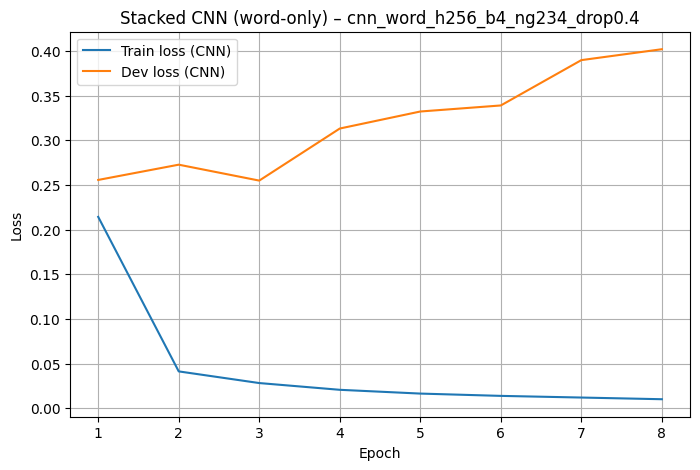

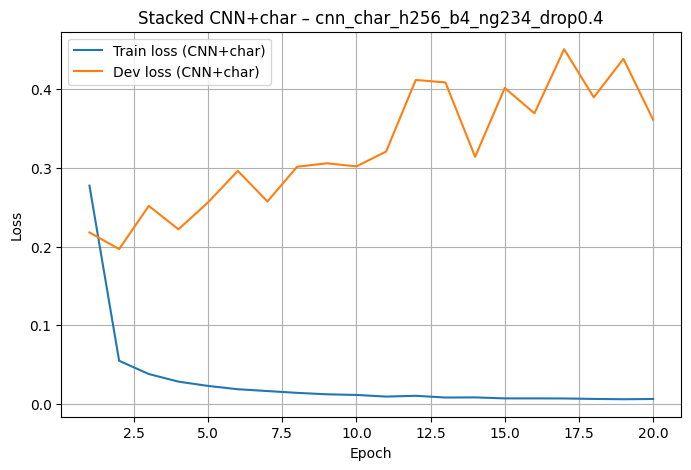

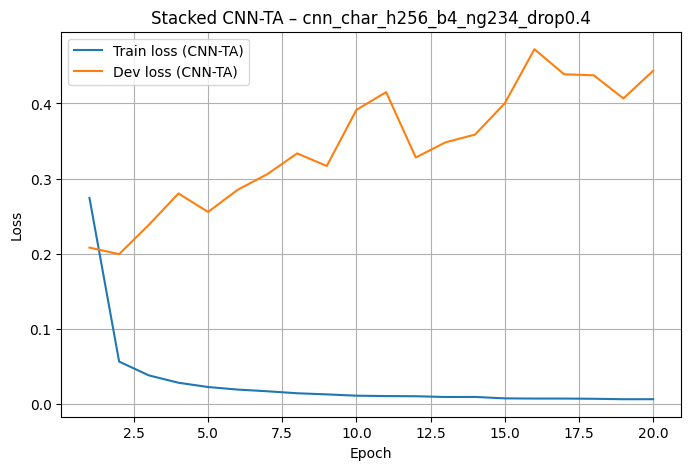

In [ ]:
# ===== Plot loss curves for best CNN models =====

# word-only CNN
plt.figure(figsize=(8,5))
epochs = range(1, len(best_cnn_word_history["train_loss"])+1)
plt.plot(epochs, best_cnn_word_history["train_loss"], label="Train loss (CNN)")
plt.plot(epochs, best_cnn_word_history["dev_loss"],   label="Dev loss (CNN)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Stacked CNN (word-only) – {best_cnn_word_config['name']}")
plt.legend()
plt.grid(True)
plt.show()

# CNN+char
plt.figure(figsize=(8,5))
epochs = range(1, len(best_cnn_char_history["train_loss"])+1)
plt.plot(epochs, best_cnn_char_history["train_loss"], label="Train loss (CNN+char)")
plt.plot(epochs, best_cnn_char_history["dev_loss"],   label="Dev loss (CNN+char)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Stacked CNN+char – {best_cnn_char_config['name']}")
plt.legend()
plt.grid(True)
plt.show()

# CNN-TA
plt.figure(figsize=(8,5))
epochs = range(1, len(cnn_ta_history["train_loss"])+1)
plt.plot(epochs, cnn_ta_history["train_loss"], label="Train loss (CNN-TA)")
plt.plot(epochs, cnn_ta_history["dev_loss"],   label="Dev loss (CNN-TA)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Stacked CNN-TA – {best_cnn_char_config['name']}")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ===== Evaluate CNN variants and extend comparison tables =====

eval_batch_size = 64

# loaders for word-only CNN
train_seq_loader_cnn = DataLoader(
    train_seq_dataset, batch_size=eval_batch_size,
    shuffle=False, collate_fn=collate_sentences
)
dev_seq_loader_cnn = DataLoader(
    dev_seq_dataset,   batch_size=eval_batch_size,
    shuffle=False, collate_fn=collate_sentences
)
test_seq_loader_cnn = DataLoader(
    test_seq_dataset,  batch_size=eval_batch_size,
    shuffle=False, collate_fn=collate_sentences
)

# loaders for CNN+char / CNN-TA
train_seq_loader_cnn_char = DataLoader(
    train_seq_dataset_chars, batch_size=eval_batch_size,
    shuffle=False, collate_fn=collate_sentences_with_chars
)
dev_seq_loader_cnn_char = DataLoader(
    dev_seq_dataset_chars,   batch_size=eval_batch_size,
    shuffle=False, collate_fn=collate_sentences_with_chars
)
test_seq_loader_cnn_char = DataLoader(
    test_seq_dataset_chars,  batch_size=eval_batch_size,
    shuffle=False, collate_fn=collate_sentences_with_chars
)

# --- WORD-ONLY CNN ---
y_train_true_cnn, y_train_pred_cnn, y_train_proba_cnn = predict_seq_with_proba_cnn(
    best_cnn_word_model, train_seq_loader_cnn, device, use_chars=False
)
y_dev_true_cnn, y_dev_pred_cnn, y_dev_proba_cnn = predict_seq_with_proba_cnn(
    best_cnn_word_model, dev_seq_loader_cnn, device, use_chars=False
)
y_test_true_cnn, y_test_pred_cnn, y_test_proba_cnn = predict_seq_with_proba_cnn(
    best_cnn_word_model, test_seq_loader_cnn, device, use_chars=False
)

print("\n=== CNN (word-only) RESULTS ===")
evaluate_split_full("TRAIN (CNN)", y_train_true_cnn, y_train_pred_cnn, y_train_proba_cnn, idx2tag)
evaluate_split_full("DEV   (CNN)", y_dev_true_cnn,   y_dev_pred_cnn,   y_dev_proba_cnn,   idx2tag)
evaluate_split_full("TEST  (CNN)", y_test_true_cnn,  y_test_pred_cnn,  y_test_proba_cnn,  idx2tag)

# --- CNN + CHAR ---
y_train_true_cnn_char, y_train_pred_cnn_char, y_train_proba_cnn_char = predict_seq_with_proba_cnn(
    best_cnn_char_model, train_seq_loader_cnn_char, device, use_chars=True
)
y_dev_true_cnn_char, y_dev_pred_cnn_char, y_dev_proba_cnn_char = predict_seq_with_proba_cnn(
    best_cnn_char_model, dev_seq_loader_cnn_char, device, use_chars=True
)
y_test_true_cnn_char, y_test_pred_cnn_char, y_test_proba_cnn_char = predict_seq_with_proba_cnn(
    best_cnn_char_model, test_seq_loader_cnn_char, device, use_chars=True
)

print("\n=== CNN+char RESULTS ===")
evaluate_split_full("TRAIN (CNN+char)", y_train_true_cnn_char, y_train_pred_cnn_char, y_train_proba_cnn_char, idx2tag)
evaluate_split_full("DEV   (CNN+char)", y_dev_true_cnn_char,   y_dev_pred_cnn_char,   y_dev_proba_cnn_char,   idx2tag)
evaluate_split_full("TEST  (CNN+char)", y_test_true_cnn_char,  y_test_pred_cnn_char,  y_test_proba_cnn_char,  idx2tag)

# --- CNN-TA (temporal averaging) ---
y_train_true_cnn_ta, y_train_pred_cnn_ta, y_train_proba_cnn_ta = predict_seq_with_proba_cnn(
    cnn_ta_model, train_seq_loader_cnn_char, device, use_chars=True
)
y_dev_true_cnn_ta, y_dev_pred_cnn_ta, y_dev_proba_cnn_ta = predict_seq_with_proba_cnn(
    cnn_ta_model, dev_seq_loader_cnn_char, device, use_chars=True
)
y_test_true_cnn_ta, y_test_pred_cnn_ta, y_test_proba_cnn_ta = predict_seq_with_proba_cnn(
    cnn_ta_model, test_seq_loader_cnn_char, device, use_chars=True
)

print("\n=== CNN-TA RESULTS ===")
evaluate_split_full("TRAIN (CNN-TA)", y_train_true_cnn_ta, y_train_pred_cnn_ta, y_train_proba_cnn_ta, idx2tag)
evaluate_split_full("DEV   (CNN-TA)", y_dev_true_cnn_ta,   y_dev_pred_cnn_ta,   y_dev_proba_cnn_ta,   idx2tag)
evaluate_split_full("TEST  (CNN-TA)", y_test_true_cnn_ta,  y_test_pred_cnn_ta,  y_test_proba_cnn_ta,  idx2tag)


# ========= EXTEND THE TABLES =========

# TRAIN
train_rows = [
    make_results_row_from_preds("Baseline",          y_train_true_b,        y_train_pred_b,        y_train_proba_b,        idx2tag),
    make_results_row_from_preds("MLP (best config)", y_train_true_m,        y_train_pred_m,        y_train_proba_m,        idx2tag),
    make_results_row_from_preds("BiLSTM",            y_train_true_r,        y_train_pred_r,        y_train_proba_r,        idx2tag),
    make_results_row_from_preds("BiLSTM-char",       y_train_true_c,        y_train_pred_c,        y_train_proba_c,        idx2tag),
    make_results_row_from_preds("BiLSTM-TA",         y_train_true_ta,       y_train_pred_ta,       y_train_proba_ta,       idx2tag),
    make_results_row_from_preds("CNN",               y_train_true_cnn,      y_train_pred_cnn,      y_train_proba_cnn,      idx2tag),
    make_results_row_from_preds("CNN-char",          y_train_true_cnn_char, y_train_pred_cnn_char, y_train_proba_cnn_char, idx2tag),
    make_results_row_from_preds("CNN-TA",            y_train_true_cnn_ta,   y_train_pred_cnn_ta,   y_train_proba_cnn_ta,   idx2tag),
]
train_df = pd.DataFrame(train_rows)[cols]

# DEV
dev_rows = [
    make_results_row_from_preds("Baseline",          y_dev_true_b,        y_dev_pred_b,        y_dev_proba_b,        idx2tag),
    make_results_row_from_preds("MLP (best config)", y_dev_true_m,        y_dev_pred_m,        y_dev_proba_m,        idx2tag),
    make_results_row_from_preds("BiLSTM",            y_dev_true_r,        y_dev_pred_r,        y_dev_proba_r,        idx2tag),
    make_results_row_from_preds("BiLSTM-char",       y_dev_true_c,        y_dev_pred_c,        y_dev_proba_c,        idx2tag),
    make_results_row_from_preds("BiLSTM-TA",         y_dev_true_ta,       y_dev_pred_ta,       y_dev_proba_ta,       idx2tag),
    make_results_row_from_preds("CNN",               y_dev_true_cnn,      y_dev_pred_cnn,      y_dev_proba_cnn,      idx2tag),
    make_results_row_from_preds("CNN-char",          y_dev_true_cnn_char, y_dev_pred_cnn_char, y_dev_proba_cnn_char, idx2tag),
    make_results_row_from_preds("CNN-TA",            y_dev_true_cnn_ta,   y_dev_pred_cnn_ta,   y_dev_proba_cnn_ta,   idx2tag),
]
dev_df = pd.DataFrame(dev_rows)[cols]

# TEST
test_rows = [
    make_results_row_from_preds("Baseline",          y_test_true_b,        y_test_pred_b,        y_test_proba_b,        idx2tag),
    make_results_row_from_preds("MLP (best config)", y_test_true_m,        y_test_pred_m,        y_test_proba_m,        idx2tag),
    make_results_row_from_preds("BiLSTM",            y_test_true_r,        y_test_pred_r,        y_test_proba_r,        idx2tag),
    make_results_row_from_preds("BiLSTM-char",       y_test_true_c,        y_test_pred_c,        y_test_proba_c,        idx2tag),
    make_results_row_from_preds("BiLSTM-TA",         y_test_true_ta,       y_test_pred_ta,       y_test_proba_ta,       idx2tag),
    make_results_row_from_preds("CNN",               y_test_true_cnn,      y_test_pred_cnn,      y_test_proba_cnn,      idx2tag),
    make_results_row_from_preds("CNN-char",          y_test_true_cnn_char, y_test_pred_cnn_char, y_test_proba_cnn_char, idx2tag),
    make_results_row_from_preds("CNN-TA",            y_test_true_cnn_ta,   y_test_pred_cnn_ta,   y_test_proba_cnn_ta,   idx2tag),
]
test_df = pd.DataFrame(test_rows)[cols]

pd.options.display.float_format = "{:.4f}".format

print("=== TRAIN RESULTS ===")
display(train_df)

print("\n=== DEV RESULTS ===")
display(dev_df)

print("\n=== TEST RESULTS ===")
display(test_df)



=== CNN (word-only) RESULTS ===

===== TRAIN (CNN) =====
Per-tag metrics:
Tag    ADJ | P=0.9910  R=0.9949  F1=0.9929  PR-AUC=0.9995
Tag    ADP | P=0.9940  R=0.9975  F1=0.9957  PR-AUC=0.9998
Tag    ADV | P=0.9858  R=0.9718  F1=0.9787  PR-AUC=0.9979
Tag    AUX | P=0.9988  R=0.9980  F1=0.9984  PR-AUC=0.9995
Tag  CCONJ | P=0.9748  R=0.9909  F1=0.9828  PR-AUC=0.9986
Tag    DET | P=0.9812  R=0.9802  F1=0.9807  PR-AUC=0.9984
Tag   INTJ | P=0.9874  R=0.9937  F1=0.9905  PR-AUC=0.9992
Tag   NOUN | P=0.9985  R=0.9981  F1=0.9983  PR-AUC=0.9999
Tag    NUM | P=0.9979  R=0.9845  F1=0.9912  PR-AUC=0.9976
Tag   PRON | P=0.9701  R=0.9716  F1=0.9708  PR-AUC=0.9962
Tag  PROPN | P=0.9952  R=0.9985  F1=0.9968  PR-AUC=0.9995
Tag  SCONJ | P=0.9571  R=0.9582  F1=0.9576  PR-AUC=0.9867
Tag   VERB | P=0.9997  R=0.9998  F1=0.9998  PR-AUC=1.0000

Macro-averaged:
  Macro-P:       0.9870
  Macro-R:       0.9875
  Macro-F1:      0.9873
  Macro-PR-AUC:  0.9979

===== DEV   (CNN) =====
Per-tag metrics:
Tag    ADJ | P=0

,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9845,0.9908,0.9876,0.9759,0.9765,0.9940,0.9852,0.9711,0.9726,...,0.8797,0.7775,0.9996,0.9992,0.9994,0.9989,0.9671,0.9665,0.9664,0.9384
1,MLP (best config),0.9954,0.9958,0.9956,0.9998,0.9980,0.9985,0.9983,1.0000,0.9943,...,0.9863,0.9986,0.9999,0.9997,0.9998,1.0000,0.9950,0.9946,0.9948,0.9997
2,BiLSTM,0.9990,0.9955,0.9972,1.0000,0.9991,0.9996,0.9993,1.0000,0.9978,...,0.9956,0.9998,0.9999,1.0000,1.0000,1.0000,0.9978,0.9978,0.9978,0.9999
3,BiLSTM-char,0.9946,0.9911,0.9928,0.9996,0.9942,0.9982,0.9962,0.9998,0.9922,...,0.9562,0.9894,0.9998,0.9997,0.9997,1.0000,0.9868,0.9896,0.9881,0.9984
4,BiLSTM-TA,0.9997,0.9999,0.9998,1.0000,0.9999,0.9999,0.9999,1.0000,1.0000,...,0.9996,1.0000,1.0000,1.0000,1.0000,1.0000,0.9997,0.9998,0.9998,1.0000
5,CNN,0.9910,0.9949,0.9929,0.9995,0.9940,0.9975,0.9957,0.9998,0.9858,...,0.9576,0.9867,0.9997,0.9998,0.9998,1.0000,0.9870,0.9875,0.9873,0.9979
6,CNN-char,0.9919,0.9925,0.9922,0.9996,0.9942,0.9981,0.9962,0.9999,0.9885,...,0.9629,0.9922,0.9998,0.9996,0.9997,1.0000,0.9880,0.9895,0.9887,0.9987
7,CNN-TA,0.9996,0.9990,0.9993,1.0000,0.9992,0.9999,0.9996,1.0000,0.9993,...,0.9970,1.0000,1.0000,1.0000,1.0000,1.0000,0.9987,0.9991,0.9989,1.0000



=== DEV RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9774,0.7133,0.8247,0.7125,0.9683,0.9935,0.9807,0.9624,0.9556,...,0.8419,0.7201,0.7957,0.9989,0.8858,0.7950,0.9489,0.9039,0.9211,0.8627
1,MLP (best config),0.9135,0.7243,0.8080,0.8915,0.9892,0.9902,0.9897,0.9993,0.9599,...,0.9213,0.9750,0.8636,0.9787,0.9175,0.9845,0.9490,0.9236,0.9343,0.9749
2,BiLSTM,0.8574,0.7668,0.8096,0.8969,0.9924,0.9892,0.9908,0.9993,0.9643,...,0.9261,0.9631,0.8477,0.9918,0.9141,0.9833,0.9478,0.9268,0.9355,0.9737
3,BiLSTM-char,0.9669,0.7202,0.8255,0.9062,0.9860,0.9935,0.9897,0.9991,0.9727,...,0.9198,0.9645,0.8643,0.9948,0.9250,0.9921,0.9551,0.9321,0.9413,0.9807
4,BiLSTM-TA,0.8576,0.7353,0.7917,0.8835,0.9839,0.9924,0.9881,0.9986,0.9613,...,0.8976,0.9591,0.8463,0.9809,0.9086,0.9815,0.9406,0.9207,0.9293,0.9712
5,CNN,0.9160,0.7325,0.8140,0.8794,0.9902,0.9913,0.9908,0.9991,0.9545,...,0.9091,0.9716,0.8465,0.9869,0.9113,0.9814,0.9528,0.9207,0.9346,0.9710
6,CNN-char,0.8814,0.7750,0.8248,0.9182,0.9871,0.9935,0.9903,0.9995,0.9636,...,0.9228,0.9748,0.9038,0.9880,0.9440,0.9924,0.9451,0.9374,0.9406,0.9811
7,CNN-TA,0.8691,0.7833,0.8240,0.9180,0.9860,0.9946,0.9903,0.9996,0.9679,...,0.9237,0.9720,0.8849,0.9933,0.9360,0.9948,0.9507,0.9364,0.9426,0.9811



=== TEST RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9730,0.7660,0.8571,0.7585,0.9723,0.9932,0.9827,0.9662,0.9746,...,0.8904,0.7953,0.7987,0.9976,0.8871,0.7972,0.9523,0.9197,0.9325,0.8811
1,MLP (best config),0.9181,0.7899,0.8492,0.9206,0.9932,0.9955,0.9944,0.9998,0.9664,...,0.9431,0.9817,0.8626,0.9739,0.9149,0.9807,0.9513,0.9303,0.9397,0.9766
2,BiLSTM,0.8580,0.8032,0.8297,0.9124,0.9966,0.9955,0.9960,0.9996,0.9721,...,0.9457,0.9849,0.8515,0.9820,0.9121,0.9791,0.9498,0.9335,0.9405,0.9753
3,BiLSTM-char,0.9601,0.7673,0.8529,0.9230,0.9844,0.9966,0.9905,0.9998,0.9744,...,0.9214,0.9668,0.8615,0.9928,0.9225,0.9894,0.9546,0.9360,0.9435,0.9812
4,BiLSTM-TA,0.8951,0.8059,0.8481,0.9098,0.9888,0.9944,0.9915,0.9992,0.9620,...,0.9132,0.9746,0.8486,0.9796,0.9094,0.9780,0.9447,0.9330,0.9380,0.9736
5,CNN,0.9206,0.7859,0.8479,0.9083,0.9888,0.9955,0.9921,0.9996,0.9627,...,0.9259,0.9728,0.8476,0.9767,0.9076,0.9775,0.9507,0.9283,0.9382,0.9742
6,CNN-char,0.8623,0.8245,0.8430,0.9344,0.9910,0.9966,0.9938,0.9997,0.9721,...,0.9339,0.9816,0.9023,0.9848,0.9417,0.9910,0.9482,0.9443,0.9458,0.9834
7,CNN-TA,0.8796,0.8258,0.8519,0.9346,0.9855,0.9955,0.9904,0.9997,0.9720,...,0.9315,0.9757,0.8881,0.9932,0.9377,0.9936,0.9535,0.9438,0.9481,0.9834
